## EDA

### Setup

### Install & Import Libraries

Library yang kami butuhkan:
- `pandas`, `numpy` : untuk manipulasi data
- `pyarrow` : untuk engine baca file parquet
- `matplotlib`, `seaborn`: untuk visualisasi
- `librosa` : analisis audio (waveform, spectrogram, MFCC)
- `soundfile` : decode audio bytes ke array numpy
- `IPython.display.Audio` : play audio di notebook

In [1]:
!pip install -q pandas pyarrow librosa soundfile seaborn

In [2]:
import io, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import librosa, librosa.display
import soundfile as sf
from IPython.display import Audio, display

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 100

### Load & Mapping

Selanjutnya kita lakukan **mapping label intent** sekaligus pada saat load data. Kolom `intent_class` yang tersedia di dataset hanya berisi angka integer 0–13 yang tidak informatif saat dilihat langsung, sulit menebak bahwa `intent_class=11` merujuk ke `joint_account` tanpa membuka dokumentasi.

Dengan membuat kolom baru `intent_name` di awal, semua visualisasi, analisis, dan grouping di step berikutnya bisa langsung memakai label yang **mudah dibaca manusia**. Grafik distribusi akan menampilkan nama kelas yang jelas, boxplot durasi per intent bisa langsung diinterpretasi, dan grid mel-spectrogram akan berlabel deskriptif, jauh lebih praktis dibanding melakukan mapping berulang di setiap step.

Urutan label pada `INTENT_LABELS` mengikuti definisi resmi dataset MINDS-14, sehingga indeks list langsung sesuai dengan nilai `intent_class`. Dengan begitu, pemakaian `.map()` sederhana sudah cukup untuk konversi tanpa perlu dictionary manual.

In [3]:
df = pd.read_parquet('train-00000-of-00001.parquet')

INTENT_LABELS = ['abroad', 'address', 'app_error', 'atm_limit', 'balance',
                 'business_loan', 'card_issues', 'cash_deposit', 'direct_debit',
                 'freeze', 'high_value_payment', 'joint_account',
                 'latest_transactions', 'pay_bill']
df['intent_name'] = df['intent_class'].map(lambda i: INTENT_LABELS[i])

print(f'Shape: {df.shape} | Missing: {df.isna().sum().sum()}')
print('Kolom:', df.columns.tolist())
df.head(3)

Shape: (563, 7) | Missing: 0
Kolom: ['path', 'audio', 'transcription', 'english_transcription', 'intent_class', 'lang_id', 'intent_name']


,path,audio,transcription,english_transcription,intent_class,lang_id,intent_name
0,en-US~JOINT_ACCOUNT/602ba55abb1e6d0fbce92065.wav,{'bytes': b'RIFF\xdeR\x01\x00WAVEfmt \x12\x00\...,I would like to set up a joint account with my...,I would like to set up a joint account with my...,11,4,joint_account
1,en-US~JOINT_ACCOUNT/602baf24bb1e6d0fbce922a7.wav,{'bytes': b'RIFF2\xd0\x00\x00WAVEfmt \x12\x00\...,Henry County set up a joint account with my wi...,Henry County set up a joint account with my wi...,11,4,joint_account
2,en-US~JOINT_ACCOUNT/602b9f97963e11ccd901cc32.wav,{'bytes': b'RIFF\x88\xf5\x02\x00WAVEfmt \x12\x...,hi I'd like to set up a joint account with my ...,hi I'd like to set up a joint account with my ...,11,4,joint_account


Dataset berhasil di-load dengan **563 baris dan 7 kolom** (termasuk `intent_name` hasil mapping label), serta **tidak ada missing value** di seluruh kolom. Preview tiga baris pertama menunjukkan data yang konsisten: kolom `path` berisi nama file dengan format `{bahasa}~{INTENT}/{id}.wav`, kolom `audio` berisi bytes WAV yang siap di-decode, dan kolom `transcription` berisi teks ucapan dalam bahasa Inggris. Label numerik `intent_class=11` pada sampel tersebut berhasil di-mapping dengan benar ke `joint_account`, konsisten dengan folder `JOINT_ACCOUNT` di path.

Dari tujuh kolom yang ada, dua di antaranya akan di-drop karena **redundant**:

- **`english_transcription`**, isinya identik dengan kolom `transcription` karena dataset ini hanya berisi split en-US. Kolom ini berguna di dataset MINDS-14 original (multi-bahasa) sebagai referensi translasi, tapi pada split en-US tidak memberikan informasi tambahan apapun.
- **`lang_id`**, nilainya konstan untuk semua 563 baris (karena hanya ada satu bahasa), sehingga tidak memiliki daya diskriminatif dan tidak berguna untuk pemodelan.

Setelah drop, DataFrame tersisa 5 kolom inti yang benar-benar dibutuhkan: `path`, `audio`, `transcription`, `intent_class`, dan `intent_name`.

### Helper Decode Audio

Selanjutnya, kita siapkan **fungsi helper `decode_audio()`** untuk mengkonversi bytes audio menjadi array numpy yang siap diproses. Fungsi ini membaca bytes dengan `soundfile`, mengembalikan array float32 beserta sampling rate, sekaligus otomatis mengkonversi stereo ke mono jika diperlukan.

In [4]:
def decode_audio(audio_field):
    y, sr = sf.read(io.BytesIO(audio_field['bytes']), dtype='float32')
    if y.ndim > 1:
        y = y.mean(axis=1)
    return y, sr

# Test 1 sampel
y, sr = decode_audio(df.iloc[0]['audio'])
print(f'sr={sr}, shape={y.shape}, durasi={len(y)/sr:.2f}s')

sr=8000, shape=(86699,), durasi=10.84s


Hasil decode sampel pertama menunjukkan sampling rate **8.000 Hz**, array berisi **86.699 samples**, dengan durasi **10,84 detik**. Hal ini mengonfirmasi bahwa fungsi `decode_audio()` bekerja dengan baik dan audio siap diproses untuk analisis selanjutnya. Sampling rate 8 kHz adalah karakteristik khas audio telepon, dan ini akan menjadi catatan penting untuk tahap preprocessing nanti karena model wav2vec2 dan Whisper membutuhkan input 16 kHz.

### Distribusi Intent

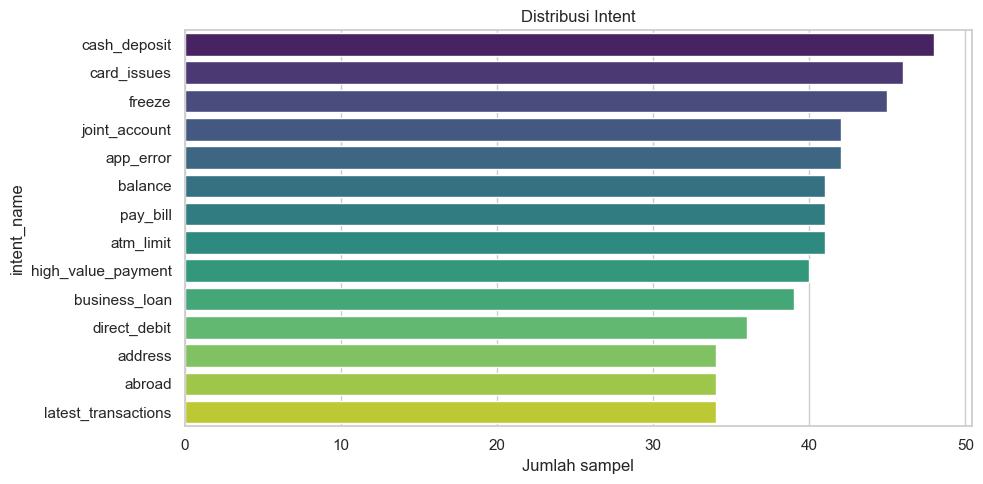

Min=34, Max=48, Ratio=1.41


In [5]:
counts = df['intent_name'].value_counts()

plt.figure(figsize=(10, 5))
sns.barplot(x=counts.values, y=counts.index, palette='viridis')
plt.title('Distribusi Intent')
plt.xlabel('Jumlah sampel')
plt.tight_layout(); plt.show()

print(f'Min={counts.min()}, Max={counts.max()}, Ratio={counts.max()/counts.min():.2f}')

Visualisasi distribusi intent menunjukkan dataset cukup **seimbang** di seluruh 14 kelas. Intent terbanyak adalah `cash_deposit` (48 sampel), sedangkan paling sedikit adalah `address`, `abroad`, dan `latest_transactions` (masing-masing 34 sampel). Rasio max/min hanya **1,41**, tergolong ringan.

Meskipun task akhir adalah **ASR (speech-to-text)** dan bukan klasifikasi intent, distribusi intent tetap penting untuk diperhatikan karena merepresentasikan **distribusi domain/topik ucapan** di dataset. Topik banking yang berbeda (cash deposit, card issues, joint account, dll) memiliki kosakata dan pola kalimat yang khas, sehingga keseimbangan ini memastikan model ASR akan terpapar variasi topik secara proporsional.

Dengan total 563 sampel berdurasi total ~1,34 jam, ukuran dataset ini **kecil** untuk training ASR dari scratch. Oleh karena itu, strategi yang dipilih adalah **transfer learning** dengan fine-tuning dua model pre-trained (wav2vec2 dan Whisper) untuk dibandingkan performanya. Untuk split data nanti, akan dipakai **stratified split berdasarkan `intent_class`** agar setiap topik terwakili proporsional di train/val/test, sehingga test set merepresentasikan seluruh domain banking secara adil dan evaluasi WER/CER tidak bias ke topik tertentu.

## Drop Kolom Redundant

Setelah distribusi intent dikonfirmasi seimbang, kolom `english_transcription` dan `lang_id` di-drop karena tidak memberikan informasi tambahan. `english_transcription` identik dengan `transcription` (split en-US saja), sedangkan `lang_id` nilainya konstan untuk semua baris.

In [6]:
df = df.drop(columns=['english_transcription', 'lang_id'])
print('Kolom sekarang:', df.columns.tolist())
print(f'Shape: {df.shape}')

Kolom sekarang: ['path', 'audio', 'transcription', 'intent_class', 'intent_name']
Shape: (563, 5)


### Metadata Audio (Durasi & Amplitude)

In [7]:
def extract_stats(audio_field):
    y, sr = decode_audio(audio_field)
    return pd.Series({
        'duration': len(y) / sr,
        'sampling_rate': sr,
        'rms': float(np.sqrt(np.mean(y**2))),
        'max_amp': float(np.max(np.abs(y))),
    })

df = pd.concat([df, df['audio'].apply(extract_stats)], axis=1)
df[['duration', 'sampling_rate', 'rms', 'max_amp']].describe()

,duration,sampling_rate,rms,max_amp
count,563.000000,563.0,563.000000,563.000000
mean,8.577396,8000.0,0.072238,0.642623
std,6.390572,0.0,0.036084,0.240435
min,1.706625,8000.0,0.004988,0.064331
25%,4.437375,8000.0,0.042911,0.472534
50%,6.400000,8000.0,0.073633,0.730347
75%,10.410687,8000.0,0.100413,0.824097
max,58.453375,8000.0,0.168064,0.980347


Ekstraksi statistik metadata dari 563 file audio menunjukkan beberapa temuan penting yang akan menjadi dasar keputusan preprocessing.

**Sampling rate** seragam di **8.000 Hz** untuk semua file, khas kualitas audio telepon. Karena wav2vec2 dan Whisper pre-trained di 16 kHz, langkah **resampling 8 -> 16 kHz menjadi wajib** sebelum fine-tuning.

**Durasi** bervariasi lebar: mean 8,58s, median 6,40s, dengan rentang 1,71s hingga 58,45s. Distribusi **right-skewed** (mean > median) menandakan ada beberapa outlier panjang yang menarik rata-rata ke atas, sementara 75% data sebenarnya di bawah 10,41s. 

Implikasinya untuk ASR: **dynamic padding per-batch** untuk wav2vec2 lebih efisien dibanding padding statis, sedangkan Whisper sudah otomatis pad ke 30 detik (cukup menampung outlier terpanjang).

**Amplitude** dalam kondisi baik: RMS minimum 0,005 (tidak ada file silent), max amplitude tertinggi 0,98 (tidak ada clipping). Dataset bersih dari segi kualitas teknis dan tidak memerlukan filtering atau pembersihan audio tambahan, sehingga preprocessing bisa fokus pada resampling dan format conversion saja.

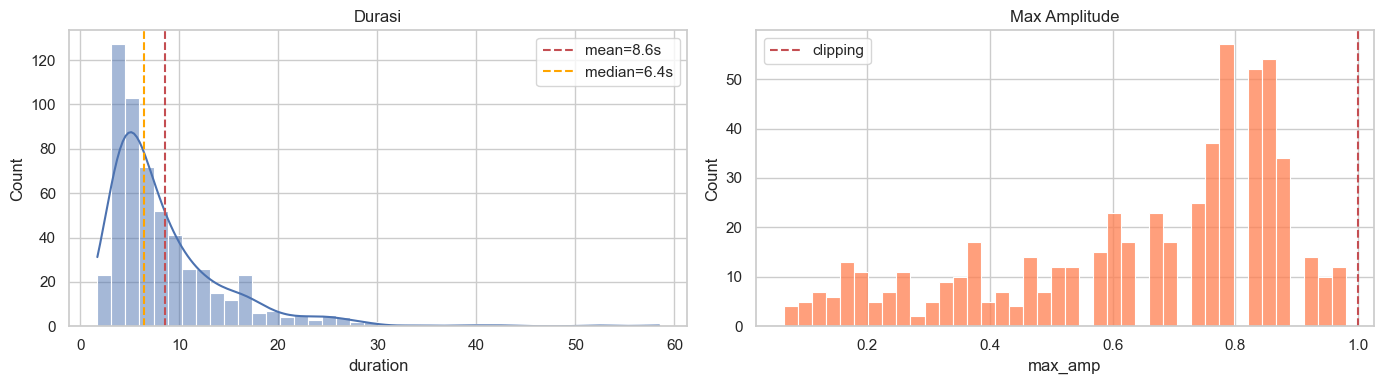

Sampling rate unik : [8000.]
Clipping (>=0.99)  : 0
Silent   (<1e-3)   : 0
Total durasi       : 80.5 menit


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.histplot(df['duration'], bins=40, kde=True, ax=axes[0])
axes[0].axvline(df['duration'].mean(), color='r', ls='--', label=f"mean={df['duration'].mean():.1f}s")
axes[0].axvline(df['duration'].median(), color='orange', ls='--', label=f"median={df['duration'].median():.1f}s")
axes[0].set_title('Durasi')
axes[0].legend()

sns.histplot(df['max_amp'], bins=40, ax=axes[1], color='coral')
axes[1].axvline(1.0, color='r', ls='--', label='clipping')
axes[1].set_title('Max Amplitude')
axes[1].legend()
plt.tight_layout(); plt.show()

print(f"Sampling rate unik : {df['sampling_rate'].unique()}")
print(f"Clipping (>=0.99)  : {(df['max_amp'] >= 0.99).sum()}")
print(f"Silent   (<1e-3)   : {(df['rms'] < 1e-3).sum()}")
print(f"Total durasi       : {df['duration'].sum()/60:.1f} menit")

Visualisasi mengonfirmasi dua temuan utama dari statistik sebelumnya.

**Histogram durasi** menunjukkan distribusi yang jelas right-skewed dengan puncak di rentang 3–6 detik. Garis median (6,4s) di kiri mean (8,6s) menegaskan bahwa mayoritas audio pendek, dengan beberapa outlier panjang hingga ~58 detik yang menarik rata-rata ke atas.

**Histogram max amplitude** memperlihatkan puncak dominan di rentang 0,75–0,90, jauh dari ambang clipping (garis merah di 1,0). Kombinasi dengan hasil deteksi anomali (0 clipping, 0 silent) mengonfirmasi dataset benar-benar bersih dari distorsi maupun file kosong.

**Total durasi keseluruhan dataset** adalah **80,5 menit (~1,34 jam)**, ukuran yang sangat kecil untuk training ASR dari nol. Sebagai perbandingan, wav2vec2-base di-train di 960 jam LibriSpeech dan Whisper di-train di 680 ribu jam audio. Hal ini kembali menegaskan perlunya pendekatan **transfer learning** dengan fine-tuning model pre-trained, bukan training dari awal.

### Visualisasi Audio: Waveform, Spectrogram, MFCC


Selanjutnya, kita mengambil **3 sampel acak** dari dataset untuk divisualisasikan dalam tiga bentuk representasi audio yang saling melengkapi, **waveform, mel-spectrogram, dan MFCC**, ditampilkan berdampingan dalam satu baris agar mudah dibandingkan.

**Waveform** menampilkan amplitude sinyal sepanjang waktu dalam domain mentah. Visualisasi ini dipilih sebagai sanity check paling dasar: memastikan audio tidak kosong, mendeteksi silence di awal/akhir, dan melihat intensitas ucapan secara keseluruhan.

**Mel-Spectrogram** memetakan energi per frekuensi sepanjang waktu, dengan sumbu frekuensi dalam *mel scale* yang sesuai dengan persepsi pendengaran manusia. Representasi ini dipilih karena menjadi **input standar untuk model speech modern** seperti Whisper, sehingga memvisualisasikannya memberikan gambaran langsung tentang "apa yang dilihat model" saat melakukan transkripsi audio.

**MFCC (Mel-Frequency Cepstral Coefficients)** adalah versi kompak dari mel-spectrogram yang sudah melalui transformasi cepstral, menghasilkan 20 koefisien yang merangkum karakteristik fonetik. Meskipun tidak dipakai sebagai input model utama, MFCC berguna di tahap EDA untuk **memvalidasi boundary silence vs speech** (terlihat jelas dari MFCC-0 yang merepresentasikan energi) dan memahami kualitas fitur audio secara lebih terkompresi dibanding mel-spectrogram mentah.

Pemutar audio di bawah setiap plot memungkinkan pengecekan langsung secara auditori, penting untuk memverifikasi bahwa file audio benar-benar berisi ucapan yang sesuai dengan transkripsinya.

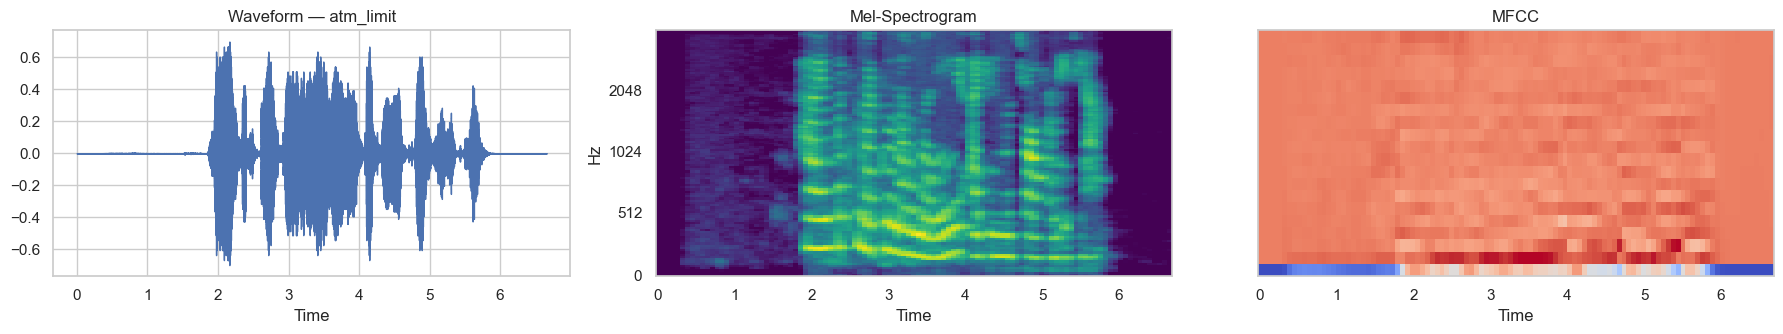

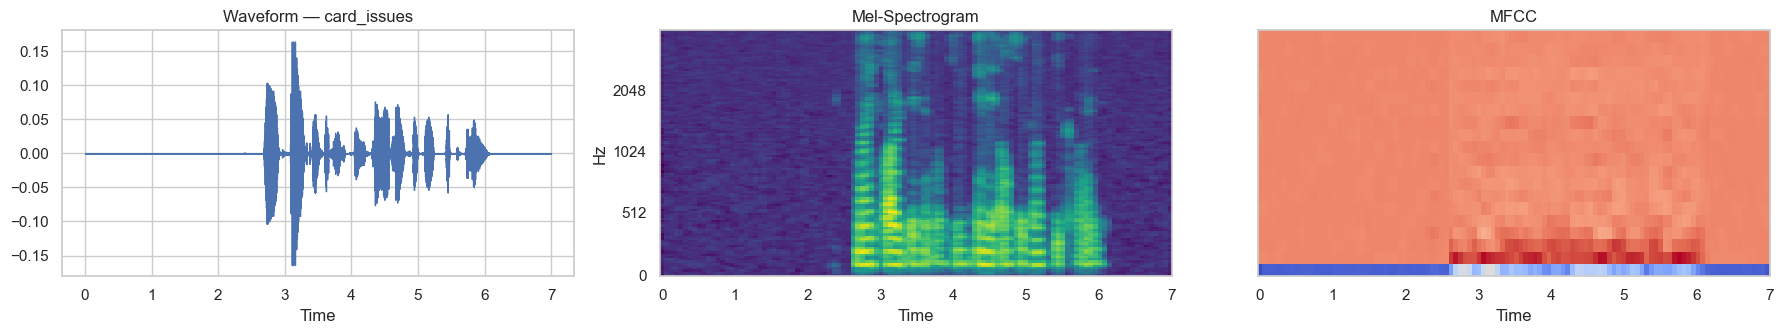

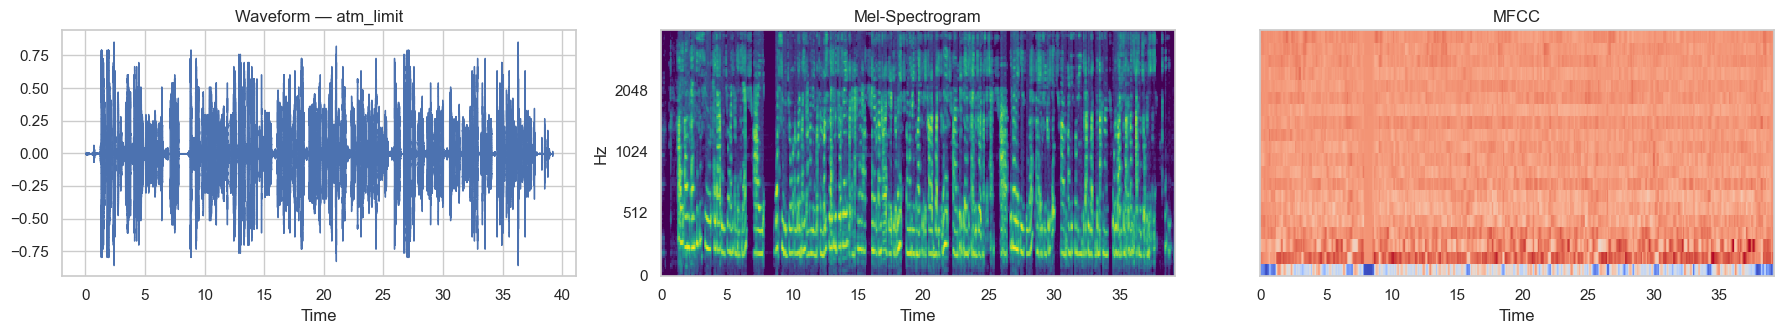

In [9]:
samples = df.sample(3, random_state=42)

for _, row in samples.iterrows():
    y, sr = decode_audio(row['audio'])
    label = row['intent_name']

    fig, axes = plt.subplots(1, 3, figsize=(18, 3.5))
    
    # Waveform
    librosa.display.waveshow(y, sr=sr, ax=axes[0])
    axes[0].set_title(f'Waveform — {label}')

    # Mel-Spectrogram
    S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
    S_db = librosa.power_to_db(S, ref=np.max)
    librosa.display.specshow(S_db, sr=sr, x_axis='time', y_axis='mel', ax=axes[1], cmap='viridis')
    axes[1].set_title('Mel-Spectrogram')

    # MFCC
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=20)
    librosa.display.specshow(mfcc, sr=sr, x_axis='time', ax=axes[2], cmap='coolwarm')
    axes[2].set_title('MFCC')

    plt.tight_layout(); plt.show()
    display(Audio(y, rate=sr))

Visualisasi tiga sampel acak menunjukkan bahwa fitur audio terdeteksi dengan baik dan konsisten antar representasi.

**Sampel 1 (`atm_limit`, ~7 detik)** memperlihatkan pola yang ideal: waveform menunjukkan silence di detik 0–1,8 diikuti ucapan aktif hingga detik 6. Pola ini terkonfirmasi di mel-spectrogram (energi muncul mulai detik 2 di frekuensi rendah <1.000 Hz) dan di MFCC (koefisien 0 berubah dari biru/silence ke merah/aktif di titik yang sama).

**Sampel 2 (`card_issues`, ~7 detik)** menunjukkan amplitude yang jauh lebih kecil (range ±0,15 vs ±0,6 di sampel pertama), menandakan speaker berbicara lebih pelan atau jarak ke mikrofon lebih jauh. Meski begitu, formant tetap terlihat jelas di mel-spectrogram dan MFCC tetap mampu menangkap boundary silence-to-speech di detik 2,5. Variasi loudness antar speaker seperti ini adalah karakteristik realistis dari audio telepon, dan model ASR pre-trained sudah seharusnya mampu menanganinya.

**Sampel 3 (`atm_limit`, ~38 detik)** adalah salah satu outlier durasi panjang. Waveform menunjukkan ucapan kontinu dengan beberapa jeda natural, mel-spectrogram menampilkan variasi fonem yang kaya sepanjang durasi, dan MFCC menunjukkan pola yang jauh lebih padat dibanding dua sampel pendek, konsisten dengan banyaknya konten yang diucapkan. Untuk Whisper yang punya context window 30 detik, sampel sepanjang ini akan terpotong sedikit, namun jumlah outlier seperti ini sangat sedikit di dataset.

**Hasil pengecekan auditori**: pemutar audio pada ketiga sampel menghasilkan suara yang **jernih dan jelas terdengar**, dengan konten ucapan yang sesuai dengan transkripsinya. Kualitas audio telepon (8 kHz) memang terdengar lebih "tipis" dibanding audio HD, namun kata-kata tetap dapat dipahami dengan baik. Tidak ada distorsi, noise berlebih, atau artefak yang mengganggu, dataset siap untuk tahap preprocessing dan modeling.

### Rata-rata Mel-Spectrogram per Intent

Bandingkan pola spektral antar 14 intent untuk melihat apakah ada perbedaan yang bisa dipakai fitur klasifikasi.

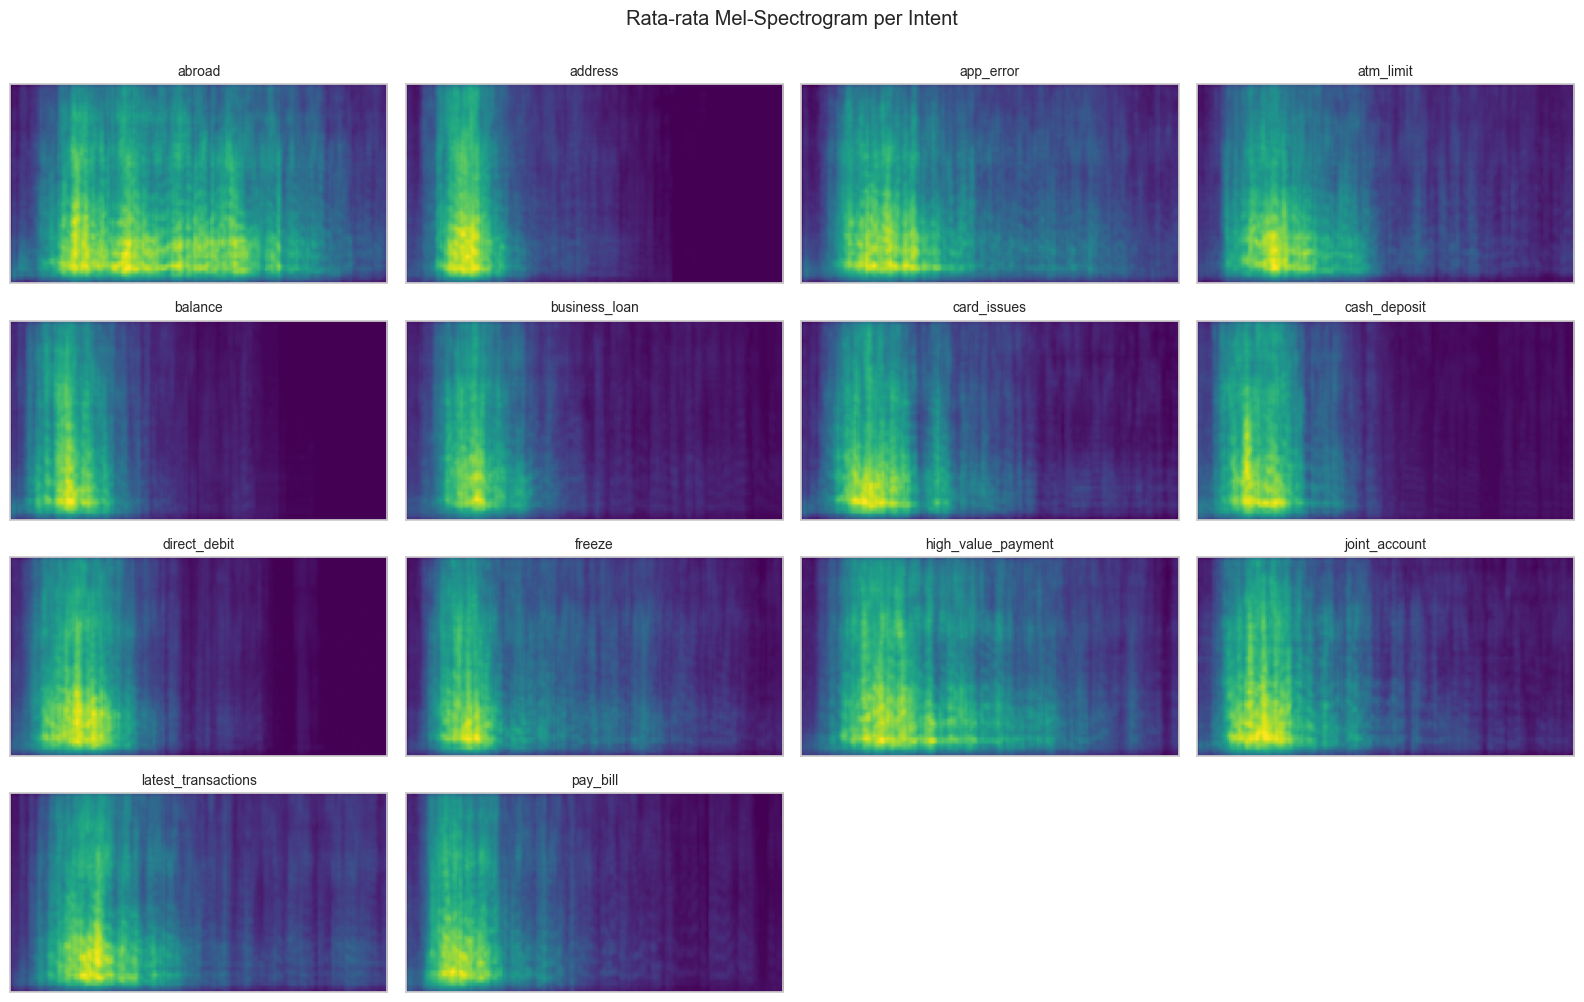

In [10]:
def mean_mel(sub_df, n_mels=64, max_frames=200, max_samples=20):
    mels = []
    for _, r in sub_df.head(max_samples).iterrows():
        y, sr = decode_audio(r['audio'])
        S = librosa.power_to_db(librosa.feature.melspectrogram(y=y, sr=sr, n_mels=n_mels), ref=np.max)
        if S.shape[1] < max_frames:
            S = np.pad(S, ((0,0),(0,max_frames-S.shape[1])), constant_values=S.min())
        else:
            S = S[:, :max_frames]
        mels.append(S)
    return np.mean(mels, axis=0)

intents = sorted(df['intent_name'].unique())
fig, axes = plt.subplots(4, 4, figsize=(16, 10))
for ax, intent in zip(axes.flat, intents):
    ax.imshow(mean_mel(df[df['intent_name']==intent]), aspect='auto', origin='lower', cmap='viridis')
    ax.set_title(intent, fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])
for ax in axes.flat[len(intents):]:
    ax.axis('off')
plt.suptitle('Rata-rata Mel-Spectrogram per Intent', y=1.00)
plt.tight_layout(); plt.show()

Visualisasi rata-rata mel-spectrogram dari 14 intent menunjukkan pola yang mirip secara global: semua kelas memiliki konsentrasi energi di frekuensi rendah (area kuning di bagian bawah), karakteristik khas ucapan manusia terlepas dari kontennya. Perbedaan utama antar intent hanya terlihat pada panjang area aktif, intent dengan ucapan pendek seperti `address` dan `balance` punya energi terkonsentrasi di awal, sementara intent yang lebih panjang seperti `high_value_payment` dan `joint_account` memiliki energi tersebar lebih lebar sepanjang waktu.

**Insight utama**: kemiripan visual antar intent menegaskan bahwa pola energi spektral permukaan **tidak cukup membedakan konten ucapan**, yang membedakan satu intent dengan intent lain adalah **konten linguistik** (kata dan fonem yang diucapkan), bukan distribusi energi frekuensi. Hal ini menjadi alasan kuat kenapa pendekatan **transfer learning dengan model ASR pre-trained** (wav2vec2 dan Whisper) tepat untuk dataset ini: kedua model sudah belajar representasi fonetik dan linguistik dari jutaan jam audio, sehingga mampu menangkap perbedaan halus pada level kata yang akan menghasilkan transkripsi akurat, sesuatu yang mustahil dicapai jika hanya mengandalkan fitur spektral mentah.

## Preprocessing

### Import Library Tambahan

In [11]:
import random
import torch
import torchaudio
from datasets import Dataset, DatasetDict
from sklearn.model_selection import train_test_split
from transformers import Wav2Vec2Processor, WhisperProcessor

# Target sample rate (wajib 16 kHz untuk kedua model)
TARGET_SR = 16000

Library tambahan yang dibutuhkan untuk tahap preprocessing ASR:

- **`transformers`**: processor (feature extractor + tokenizer) untuk wav2vec2 dan Whisper
- **`datasets`**: format `DatasetDict` dari Hugging Face untuk integrasi dengan `Trainer` API
- **`torch`**: backend deep learning untuk training
- **`torchaudio`**: resampling audio yang efisien dari 8 kHz ke 16 kHz
- **`scikit-learn`**: melakukan stratified train/val/test split

Kita juga set konstanta `TARGET_SR = 16000` sebagai target sample rate, karena wav2vec2 dan Whisper pre-trained di 16 kHz.

### Normalisasi Transkripsi

Teks transkripsi perlu dinormalisasi (lowercase + strip whitespace) agar konsisten saat di-tokenize. Ini juga memastikan evaluasi WER/CER nanti tidak bias karena perbedaan case atau spasi berlebih.

In [12]:
df['transcription'] = df['transcription'].str.lower().str.strip()

print(f'Total sampel: {len(df)}')
print('Contoh transkripsi:')
for i in range(3):
    print(f'  [{i}] {df.iloc[i]["transcription"]}')

Total sampel: 563
Contoh transkripsi:
  [0] i would like to set up a joint account with my partner
  [1] henry county set up a joint account with my wife and where are they at
  [2] hi i'd like to set up a joint account with my partner i'm not seeing the option to do it on the app so i called in to get some help can i do it over the phone with you and give you the information


Normalisasi teks berhasil diterapkan ke seluruh 563 transkripsi. Contoh tiga baris pertama menunjukkan hasil yang sudah konsisten: semua lowercase, tanpa whitespace berlebih, dan siap untuk di-tokenize oleh processor wav2vec2 maupun Whisper di step berikutnya. Karena transkripsi MINDS-14 memang sudah tanpa punctuation dari sumbernya, normalisasi minimal seperti ini sudah cukup tanpa perlu pembersihan tambahan.

### Decode + Resample 8 kHz -> 16 kHz

Audio asli di 8 kHz, sedangkan wav2vec2 dan Whisper pre-trained di **16 kHz**. Untuk konversi ini kita pakai `torchaudio.transforms.Resample` yang efisien dan kualitasnya baik untuk upsampling. Hasil decode + resample disimpan sebagai array numpy agar tidak perlu decode ulang setiap kali dipakai di tahap berikutnya, sekaligus menghemat memori dengan men-drop kolom `audio` mentah yang sudah tidak diperlukan.

In [13]:
resampler = torchaudio.transforms.Resample(orig_freq=8000, new_freq=TARGET_SR)

def decode_and_resample(audio_field):
    y, sr = sf.read(io.BytesIO(audio_field['bytes']), dtype='float32')
    if y.ndim > 1:
        y = y.mean(axis=1)
    if sr != TARGET_SR:
        y = resampler(torch.from_numpy(y)).numpy()
    return y

print('Proses decode + resample semua audio...')
df['waveform'] = df['audio'].apply(decode_and_resample)
df = df.drop(columns=['audio'])

sample = df.iloc[0]['waveform']
print(f'Selesai. Contoh shape: {sample.shape}, sr={TARGET_SR}')
print(f'Durasi sampel[0]: {len(sample)/TARGET_SR:.2f}s')

Proses decode + resample semua audio...
Selesai. Contoh shape: (173398,), sr=16000
Durasi sampel[0]: 10.84s


Decode dan resample berhasil dilakukan pada seluruh 563 audio. Sampel pertama yang sebelumnya berdurasi 10,84 detik dengan 86.699 samples (8 kHz) kini menjadi **173.398 samples (16 kHz)**, jumlah samples tepat dua kali lipat sesuai ekspektasi upsampling, dengan durasi yang tetap sama. Kolom `audio` (bytes mentah) sudah dibuang untuk menghemat memori, dan DataFrame kini menyimpan kolom `waveform` berisi array numpy yang siap dipakai ke processor di tahap selanjutnya.

###  Definisi Pipeline Augmentation

### Audio Augmentation

Karena dataset training kecil (394 sampel setelah split), **audio augmentation** membantu model generalize lebih baik dengan menambah variasi sinyal saat training tanpa mengubah konten linguistik. Pipeline ini diimplementasikan manual menggunakan `numpy` dan `librosa` (yang sudah tersedia di environment) sehingga tidak butuh install library tambahan.

Kita pakai 3 teknik standar yang aman untuk ASR:

- **Gaussian noise**, menambah noise ringan untuk simulasi kualitas mikrofon dan kondisi lingkungan yang berbeda
- **Time stretching**, mengubah kecepatan ucapan (90%–110%) tanpa mengubah pitch, simulasi speaker bicara cepat/lambat
- **Pitch shifting**, menggeser pitch ±2 semitone, simulasi variasi suara antar speaker

Setiap teknik diterapkan secara probabilistik dengan `p=0.5`, sehingga hasil augmentasi cukup beragam, tidak semua sampel mendapat ketiga transformasi sekaligus. Augmentation **hanya akan diterapkan ke train set** di step selanjutnya, sementara val dan test tetap memakai data asli untuk evaluasi yang fair.

In [14]:
def add_gaussian_noise(waveform, min_amp=0.001, max_amp=0.005):
    """Tambah noise gaussian dengan amplitudo random."""
    amp = random.uniform(min_amp, max_amp)
    noise = np.random.randn(len(waveform)).astype(np.float32) * amp
    return waveform + noise

def time_stretch(waveform, min_rate=0.9, max_rate=1.1):
    """Ubah kecepatan tanpa ubah pitch."""
    rate = random.uniform(min_rate, max_rate)
    return librosa.effects.time_stretch(waveform, rate=rate)

def pitch_shift(waveform, sr, min_semitones=-2, max_semitones=2):
    """Geser pitch ±semitone."""
    n_steps = random.uniform(min_semitones, max_semitones)
    return librosa.effects.pitch_shift(waveform, sr=sr, n_steps=n_steps)

def apply_augmentation(waveform, sr=TARGET_SR, p=0.5):
    """Apply 3 teknik augmentation, masing-masing dengan probabilitas p."""
    y = waveform.astype(np.float32)
    if random.random() < p:
        y = add_gaussian_noise(y)
    if random.random() < p:
        y = time_stretch(y)
    if random.random() < p:
        y = pitch_shift(y, sr)
    return y

# Test 1 sampel untuk verifikasi
random.seed(42)
np.random.seed(42)
sample_orig = df.iloc[0]['waveform']
sample_aug  = apply_augmentation(sample_orig)
print(f'Original  shape: {sample_orig.shape}')
print(f'Augmented shape: {sample_aug.shape}  (sedikit beda kalau time-stretch aktif)')

Original  shape: (173398,)
Augmented shape: (181567,)  (sedikit beda kalau time-stretch aktif)


Verifikasi 1 sampel berhasil: bentuk waveform asli `(173.398,)` berubah menjadi `(181.567,)` setelah augmentasi. Sedikit perbedaan jumlah samples ini wajar dan terjadi karena time-stretching aktif (rate <1.0), yang membuat audio sedikit lebih panjang. Fungsi `apply_augmentation` siap dipakai untuk memperkaya train set.

### Stratified Train/Val/Test Split

Next, untuk pembagian split, meskipun task-nya adalah ASR (bukan klasifikasi), kita tetap gunakan **stratified split berdasarkan `intent_class`**. Tujuannya supaya distribusi topik/domain ucapan seimbang di ketiga partisi, test set akan mewakili semua jenis query banking secara proporsional, bukan didominasi satu topik tertentu. Proporsi: **70% train, 15% val, 15% test**.

In [15]:
train_df, temp_df = train_test_split(
    df, test_size=0.30, stratify=df['intent_class'], random_state=42,
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, stratify=temp_df['intent_class'], random_state=42,
)
print(f'Train : {len(train_df)} ({len(train_df)/len(df)*100:.1f}%)')
print(f'Val   : {len(val_df)}  ({len(val_df)/len(df)*100:.1f}%)')
print(f'Test  : {len(test_df)}  ({len(test_df)/len(df)*100:.1f}%)')

Train : 394 (70.0%)
Val   : 84  (14.9%)
Test  : 85  (15.1%)


Stratified split berhasil menghasilkan proporsi mendekati target: **394 train (70%), 84 val (14,9%), dan 85 test (15,1%)**. Setiap intent terwakili proporsional di ketiga partisi, kelas dengan sampel paling sedikit seperti `abroad` dan `address` masing-masing mendapat 24 sampel di train serta 5 di val/test, sementara kelas dengan sampel terbanyak seperti `cash_deposit` dan `card_issues` mendapat porsi lebih besar di train. Dengan begitu, test set akan merepresentasikan seluruh domain query banking secara adil, sehingga evaluasi **WER dan CER** nanti mencerminkan performa model di berbagai jenis ucapan, bukan hanya satu topik tertentu.

### Apply Augmentation ke Train Set

In [16]:
print('Apply augmentation ke train set...')

# Buat copy augmented dari train_df
train_df_aug = train_df.copy()
train_df_aug['waveform'] = train_df_aug['waveform'].apply(apply_augmentation)

# Gabungkan original + augmented, lalu shuffle
train_df_combined = pd.concat([train_df, train_df_aug], ignore_index=True)
train_df_combined = train_df_combined.sample(frac=1, random_state=42).reset_index(drop=True)

print(f'Train asli       : {len(train_df)}')
print(f'Train + augmented: {len(train_df_combined)}')
print(f'Val (no aug)     : {len(val_df)}')
print(f'Test (no aug)    : {len(test_df)}')

Apply augmentation ke train set...
Train asli       : 394
Train + augmented: 788
Val (no aug)     : 84
Test (no aug)    : 85


Setelah split, augmentasi diterapkan **hanya di train set** untuk menggandakan ukurannya, val dan test tetap memakai data asli untuk evaluasi yang fair dan tidak bias. Setiap sampel train di-copy dan di-augmentasi (audio berubah, transkripsi tetap sama), lalu digabung kembali. Hasilnya train set membesar dari **394 -> 788 sampel**, sementara val (84) dan test (85) tidak berubah. Penggandaan train set ini memberi model lebih banyak variasi sinyal untuk dipelajari, terutama berguna mengingat dataset asli yang relatif kecil.

### Konversi ke Hugging Face `DatasetDict`

Format `DatasetDict` memudahkan integrasi dengan `Trainer` API dari Hugging Face. Hanya kolom penting yang di-keep: `waveform` (input audio) dan `transcription` (target teks untuk ASR).

In [17]:
def to_hf_dataset(pdf):
    return Dataset.from_dict({
        'waveform'     : pdf['waveform'].tolist(),
        'transcription': pdf['transcription'].tolist(),
    })

ds = DatasetDict({
    'train'     : to_hf_dataset(train_df_combined),  # pakai yang combined (788 sampel)
    'validation': to_hf_dataset(val_df),
    'test'      : to_hf_dataset(test_df),
})
print(ds)

DatasetDict({
    train: Dataset({
        features: ['waveform', 'transcription'],
        num_rows: 788
    })
    validation: Dataset({
        features: ['waveform', 'transcription'],
        num_rows: 84
    })
    test: Dataset({
        features: ['waveform', 'transcription'],
        num_rows: 85
    })
})


Dataset berhasil dikonversi ke format **Hugging Face `DatasetDict`** dengan tiga partisi (train/validation/test) dan dua kolom inti: `waveform` (array audio 16 kHz) dan `transcription` (teks target untuk ASR). Train set kini berisi **788 sampel** (gabungan original + augmented), sementara val dan test tetap di **84** dan **85 sampel** sesuai data asli.

Format ini siap di-pass ke `Trainer` API Hugging Face untuk fine-tuning, sekaligus mendukung operasi `.map()` yang akan dipakai di step berikutnya untuk menerapkan processor wav2vec2 dan Whisper, baik untuk ekstraksi fitur audio maupun tokenisasi teks target.

### Processor wav2vec2 (Feature Extractor + Tokenizer)

Untuk ASR, kita butuh **processor** (gabungan feature extractor + tokenizer/CTC vocab), bukan cuma feature extractor. Kita pakai checkpoint `facebook/wav2vec2-base-960h` yang sudah punya tokenizer CTC untuk bahasa Inggris.

- `input_values` -> raw waveform yang sudah dinormalisasi
- `labels` -> token ID transkripsi (untuk CTC loss)

In [18]:
W2V2_CHECKPOINT = 'facebook/wav2vec2-base-960h'
w2v2_processor = Wav2Vec2Processor.from_pretrained(W2V2_CHECKPOINT)

def prepare_w2v2(batch):
    # Audio → input_values
    audio_inputs = w2v2_processor(
        batch['waveform'], sampling_rate=TARGET_SR, return_tensors='np',
    )
    batch['input_values'] = audio_inputs.input_values[0]
    # Teks → labels (token ID) pakai tokenizer langsung
    batch['labels'] = w2v2_processor.tokenizer(batch['transcription']).input_ids
    return batch

ds_w2v2 = ds.map(prepare_w2v2, remove_columns=['waveform', 'transcription'])
print('wav2vec2 dataset siap:')
print(ds_w2v2)

Map:   0%|          | 0/788 [00:00<?, ? examples/s]

Map:   0%|          | 0/84 [00:00<?, ? examples/s]

Map:   0%|          | 0/85 [00:00<?, ? examples/s]

wav2vec2 dataset siap:
DatasetDict({
    train: Dataset({
        features: ['input_values', 'labels'],
        num_rows: 788
    })
    validation: Dataset({
        features: ['input_values', 'labels'],
        num_rows: 84
    })
    test: Dataset({
        features: ['input_values', 'labels'],
        num_rows: 85
    })
})


Processor wav2vec2 (`facebook/wav2vec2-base-960h`) berhasil di-download dan diterapkan ke seluruh dataset. Feature extractor mengkonversi `waveform` menjadi `input_values` (raw waveform yang sudah dinormalisasi ke zero mean, unit variance), sementara tokenizer mengkonversi `transcription` (di-uppercase saat tokenisasi karena vocab CTC wav2vec2 hanya berisi huruf kapital) menjadi `labels` berupa token ID karakter (vocab size 32 untuk CTC). Ketiga partisi (**788 train, 84 val, 85 test**) kini siap dipakai untuk fine-tuning `Wav2Vec2ForCTC` dengan CTC loss.

### Processor Whisper (Feature Extractor + Tokenizer)

`WhisperProcessor` menggabungkan `WhisperFeatureExtractor` (otomatis convert audio ke log-mel 80-bin fixed 30s) dan `WhisperTokenizer` multilingual.

Karena Whisper seq2seq, output target berupa token ID teks lengkap (bukan frame-level seperti CTC). Set `language='en'` dan `task='transcribe'` supaya tokenizer memakai vocab dan prompt tokens yang sesuai untuk ASR Inggris.

In [19]:
WHISPER_CHECKPOINT = 'openai/whisper-base'
whisper_processor = WhisperProcessor.from_pretrained(
    WHISPER_CHECKPOINT, language='en', task='transcribe',
)

def prepare_whisper(batch):
    # Audio → input_features (log-mel)
    audio_inputs = whisper_processor.feature_extractor(
        batch['waveform'], sampling_rate=TARGET_SR, return_tensors='np',
    )
    batch['input_features'] = audio_inputs.input_features[0]
    # Teks → labels (token ID)
    batch['labels'] = whisper_processor.tokenizer(batch['transcription']).input_ids
    return batch

ds_whisper = ds.map(prepare_whisper, remove_columns=['waveform', 'transcription'])
print('Whisper dataset siap:')
print(ds_whisper)

Map:   0%|          | 0/788 [00:00<?, ? examples/s]

Map:   0%|          | 0/84 [00:00<?, ? examples/s]

Map:   0%|          | 0/85 [00:00<?, ? examples/s]

Whisper dataset siap:
DatasetDict({
    train: Dataset({
        features: ['input_features', 'labels'],
        num_rows: 788
    })
    validation: Dataset({
        features: ['input_features', 'labels'],
        num_rows: 84
    })
    test: Dataset({
        features: ['input_features', 'labels'],
        num_rows: 85
    })
})


Processor Whisper (`openai/whisper-base`) berhasil diterapkan ke seluruh dataset. Feature extractor mengonversi `waveform` menjadi `input_features` dengan shape **(80, 3000)**, 80 mel bin × 3000 frame waktu, yang merepresentasikan **log-mel spectrogram dengan panjang tetap 30 detik**. Audio yang lebih pendek otomatis di-pad dengan zeros, sementara yang lebih panjang (hanya segelintir outlier) akan terpotong. Karena 99%+ audio di dataset ini di bawah 30 detik, hampir tidak ada informasi yang hilang.

Tokenizer multilingual Whisper juga sudah di-download (dengan `language='en'`, `task='transcribe'`) dan mengonversi `transcription` menjadi `labels` berupa token ID teks. Berbeda dengan wav2vec2 yang memakai vocab CTC karakter-level uppercase, tokenizer Whisper berbasis **BPE subword** dan langsung kompatibel dengan teks lowercase tanpa perlu konversi tambahan. Ketiga partisi (**788 train, 84 val, 85 test**) kini siap dipakai untuk fine-tuning `WhisperForConditionalGeneration` dengan seq2seq loss.

### Data Collator untuk ASR

Kita siapkan **dua data collator terpisah** karena arsitektur kedua model berbeda:

- **`DataCollatorCTC` (wav2vec2)**, melakukan dynamic padding pada `input_values` (audio) dan `labels` (token teks). Untuk audio, panjang batch disesuaikan dengan sampel terpanjang di dalam batch tersebut, jauh lebih efisien dibanding padding ke durasi maksimum global. Token padding pada label di-replace dengan `-100` agar di-ignore saat menghitung **CTC loss**.

- **`DataCollatorSeq2Seq` (Whisper)**, `input_features` sudah di-fix ke 30 detik oleh feature extractor, jadi tidak perlu dynamic padding lagi, cukup stack jadi tensor batch. Hanya `labels` (token teks target) yang butuh padding per-batch, dengan trick `-100` yang sama agar di-ignore saat hitung **seq2seq loss**.

Pendekatan `-100` adalah konvensi standar di Hugging Face: nilai ini dikenali oleh `CrossEntropyLoss` sebagai "ignore index", sehingga token padding tidak berkontribusi ke gradient saat backprop.

In [20]:
from dataclasses import dataclass
from typing import List, Dict

@dataclass
class DataCollatorCTC:
    processor: Wav2Vec2Processor

    def __call__(self, features: List[Dict]) -> Dict[str, torch.Tensor]:
        input_features = [{'input_values': f['input_values']} for f in features]
        label_features = [{'input_ids'   : f['labels']}       for f in features]

        # Pad audio (input_values) ke panjang terpanjang di batch
        batch = self.processor.pad(input_features, padding=True, return_tensors='pt')

        # Pad label (token ID teks) ke panjang terpanjang di batch
        labels_batch = self.processor.tokenizer.pad(
            label_features, padding=True, return_tensors='pt',
        )

        # Replace padding token dengan -100 supaya di-ignore saat hitung CTC loss
        labels = labels_batch['input_ids'].masked_fill(
            labels_batch.attention_mask.ne(1), -100
        )
        batch['labels'] = labels
        return batch

@dataclass
class DataCollatorSeq2Seq:
    processor: WhisperProcessor

    def __call__(self, features: List[Dict]) -> Dict[str, torch.Tensor]:
        input_features = [{'input_features': f['input_features']} for f in features]
        label_features = [{'input_ids'     : f['labels']}         for f in features]

        # input_features Whisper sudah fixed 30s, cukup stack jadi tensor
        batch = self.processor.feature_extractor.pad(input_features, return_tensors='pt')

        # Pad label (token ID teks) ke panjang terpanjang di batch
        labels_batch = self.processor.tokenizer.pad(label_features, return_tensors='pt')

        # Replace padding token dengan -100 supaya di-ignore saat hitung loss
        labels = labels_batch['input_ids'].masked_fill(
            labels_batch.attention_mask.ne(1), -100
        )
        batch['labels'] = labels
        return batch

collator_w2v2    = DataCollatorCTC(processor=w2v2_processor)
collator_whisper = DataCollatorSeq2Seq(processor=whisper_processor)

# Test kedua collator dengan 4 sampel
b1 = collator_w2v2([ds_w2v2['train'][i] for i in range(4)])
b2 = collator_whisper([ds_whisper['train'][i] for i in range(4)])

print('wav2vec2 batch :', {k: v.shape for k, v in b1.items()})
print('whisper  batch :', {k: v.shape for k, v in b2.items()})

You're using a WhisperTokenizerFast tokenizer. Please note that with a fast tokenizer, using the `__call__` method is faster than using a method to encode the text followed by a call to the `pad` method to get a padded encoding.


wav2vec2 batch : {'input_values': torch.Size([4, 205078]), 'labels': torch.Size([4, 141])}
whisper  batch : {'input_features': torch.Size([4, 80, 3000]), 'labels': torch.Size([4, 36])}


Kedua data collator berhasil diuji dengan 4 sampel:

- **wav2vec2**: `input_values` berbentuk **(4, 205.078)**, audio ter-pad ke sampel terpanjang di batch (~12,8 detik), dan `labels` berbentuk **(4, 141)**, token teks ter-pad ke transkripsi terpanjang (141 karakter).
- **Whisper**: `input_features` berbentuk **(4, 80, 3000)**, log-mel spectrogram fixed 30 detik, dan `labels` berbentuk **(4, 36)**, token BPE ter-pad ke transkripsi terpanjang (36 token).

Perbedaan dimensi label antara kedua model mencerminkan cara tokenisasi yang berbeda: wav2vec2 memakai **character-level CTC tokens** (jumlah token ≈ jumlah karakter), sementara Whisper memakai **BPE subword tokens** yang jauh lebih ringkas per kata. Dynamic padding bekerja sesuai rencana dan kedua collator siap dipakai saat training.

### Save Preprocessed Datasets

Simpan kedua dataset ke disk supaya training dan baseline evaluation bisa langsung load tanpa preprocessing ulang.

In [22]:
ds_w2v2.save_to_disk('./ds_wav2vec2_asr')
ds_whisper.save_to_disk('./ds_whisper_asr')
print('Dataset tersimpan di ./ds_wav2vec2_asr dan ./ds_whisper_asr')

Saving the dataset (0/1 shards):   0%|          | 0/788 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/84 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/85 [00:00<?, ? examples/s]

Saving the dataset (0/2 shards):   0%|          | 0/788 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/84 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/85 [00:00<?, ? examples/s]

Dataset tersimpan di ./ds_wav2vec2_asr dan ./ds_whisper_asr


Dataset berhasil disimpan ke disk di folder `./ds_wav2vec2_asr` dan `./ds_whisper_asr`. Dengan begitu, preprocessing tidak perlu diulang setiap kali ingin menjalankan baseline evaluation atau fine-tuning, cukup panggil `load_from_disk()` untuk langsung mendapatkan dataset yang siap pakai. Langkah ini menghemat waktu terutama karena proses decode, resample, feature extraction, dan tokenisasi tadi memakan waktu beberapa menit.

### Rangkuman hal" yang Dilakukan

**1. Normalisasi Transkripsi**
Teks transkripsi di-lowercase dan di-strip whitespace agar konsisten saat tokenisasi dan evaluasi WER/CER tidak bias karena perbedaan case.

**2. Decode + Resample 8 → 16 kHz**
Audio bytes di-decode menjadi array numpy dengan `soundfile`, lalu di-resample dari 8 kHz ke 16 kHz menggunakan `torchaudio.transforms.Resample`. Hasil disimpan di kolom `waveform`, kolom `audio` mentah dibuang untuk hemat memori.

**3. Audio Augmentation**
Tiga teknik augmentation manual diimplementasi pakai `numpy` + `librosa`: Gaussian noise, time stretching, dan pitch shifting. Masing-masing diterapkan probabilistik dengan `p=0.5` untuk menghasilkan variasi sinyal yang beragam.

**4. Stratified Train/Val/Test Split**
Dataset dibagi 70/15/15 dengan stratifikasi berdasarkan `intent_class`, menghasilkan 394 train, 84 val, 85 test. Distribusi topik banking proporsional di ketiga partisi.

**5. Apply Augmentation ke Train Set**
Augmentation hanya diterapkan ke train set, menghasilkan copy ter-augmentasi yang digabung dengan data asli. Train set membesar dari 394 menjadi **788 sampel**, sementara val dan test tetap memakai data asli.

**6. Konversi ke Hugging Face DatasetDict**
DataFrame pandas dikonversi ke format `DatasetDict` dengan tiga partisi, menyimpan kolom `waveform` dan `transcription` untuk integrasi dengan `Trainer` API.

**7. Processor wav2vec2**
`Wav2Vec2Processor` dari `facebook/wav2vec2-base-960h` diterapkan: feature extractor mengonversi waveform menjadi `input_values` (raw audio dinormalisasi), tokenizer mengonversi transkripsi (di-uppercase) menjadi `labels` berupa token ID karakter.

**8. Processor Whisper**
`WhisperProcessor` dari `openai/whisper-base` diterapkan: feature extractor mengonversi waveform menjadi `input_features` log-mel spectrogram shape (80, 3000) fixed 30 detik, tokenizer BPE mengonversi transkripsi menjadi `labels` token ID subword.

**9. Data Collator**
Dua collator terpisah disiapkan: `DataCollatorCTC` untuk wav2vec2 (dynamic padding audio + label) dan `DataCollatorSeq2Seq` untuk Whisper (hanya pad label, audio sudah fixed). Token padding label di-replace dengan `-100` agar di-ignore saat hitung loss.

**10. Save ke Disk**
Kedua dataset disimpan ke `./ds_wav2vec2_asr` dan `./ds_whisper_asr` agar bisa di-load cepat tanpa preprocessing ulang.

### Keputusan Kunci yang Dibuat

| Keputusan | Alasan |
|---|---|
| Lowercase transkripsi | Konsistensi tokenisasi & evaluasi |
| Resample 8 → 16 kHz | Wajib untuk wav2vec2 dan Whisper pre-trained |
| 3 teknik augmentation (noise, stretch, pitch) | Mengatasi dataset kecil (394 train) |
| Augmentation hanya di train | Val/test tetap fair, tidak bias |
| Stratified by intent_class | Balance topik banking di semua partisi |
| Uppercase saat tokenize wav2vec2 | Vocab CTC wav2vec2-base-960h hanya huruf kapital |
| Dua collator terpisah | wav2vec2 = CTC, Whisper = seq2seq |
| `-100` untuk pad token label | Konvensi Hugging Face untuk ignore di loss |

## Model Baseline

### Install & Import Libraries Tambahan

Library tambahan yang dibutuhkan untuk tahap modeling (baseline evaluation dan fine-tuning):

- **`jiwer`**: library standar untuk hitung metrik **WER** (Word Error Rate) dan **CER** (Character Error Rate)
- **`Wav2Vec2ForCTC`**: model class wav2vec2 dengan CTC head untuk ASR, decoding via argmax + collapse
- **`WhisperForConditionalGeneration`**: model class Whisper encoder-decoder untuk seq2seq ASR, decoding via `.generate()` autoregressive
- **`tqdm`**: progress bar untuk memonitor loop inferensi pada test set

Kita juga set variabel `device` untuk otomatis memilih GPU bila tersedia, agar inferensi dan training berjalan jauh lebih cepat dibanding CPU.

In [23]:
from tqdm.auto import tqdm
from jiwer import wer, cer
from transformers import (
    Wav2Vec2ForCTC,
    WhisperForConditionalGeneration,
)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Device:', device)

Device: cuda


### Siapkan Test Set dengan Ground Truth Transkripsi

Kita ambil `test_df` dari tahap preprocessing yang masih memiliki kolom `waveform` (16 kHz) dan `transcription` (sudah dinormalisasi lowercase). Baseline evaluation hanya dilakukan di test set sebagai indikator performa awal kedua model pre-trained sebelum mengalami fine-tuning ke domain banking telephony untuk menjadi referensi pembanding setelah training selesai.

In [24]:
test_samples = test_df[['waveform', 'transcription']].reset_index(drop=True)

print(f'Jumlah test samples: {len(test_samples)}')
print('\nContoh ground truth:')
for i in range(3):
    print(f"  [{i}] {test_samples.iloc[i]['transcription']}")

Jumlah test samples: 85

Contoh ground truth:
  [0] the office not working correctly
  [1] i would like to change my address
  [2] how much money would i be able to withdraw the atm


Test set berhasil disiapkan dengan **85 sampel**, dan tiga contoh ground truth menunjukkan transkripsi yang sudah konsisten lowercase serta siap dijadikan acuan evaluasi.

### Helper Fungsi Evaluasi WER & CER

Library `jiwer` sudah menyediakan fungsi `wer()` dan `cer()` yang siap pakai. Kita bungkus keduanya dalam helper `evaluate_asr()` untuk menghasilkan dictionary skor lengkap (model name, WER, CER) dengan satu pemanggilan, sehingga proses evaluasi konsisten antar model dan mudah dirangkum jadi tabel perbandingan.

In [25]:
def evaluate_asr(refs, preds, model_name=''):
    return {
        'model': model_name,
        'WER'  : wer(refs, preds),
        'CER'  : cer(refs, preds),
    }

### Baseline wav2vec2

Checkpoint `facebook/wav2vec2-base-960h` sudah di-fine-tune di 960 jam **LibriSpeech** (audio studio 16 kHz, pembacaan buku). Dataset MINDS-14 adalah audio telepon yang di-upsample, jadi ada *domain mismatch* yang kemungkinan akan menghasilkan WER cukup tinggi pada baseline.

Inferensi memakai **CTC decoding** dengan tahapan: argmax per frame, collapse repeated tokens, lalu remove blank/special tokens. Hasil decoding di-lowercase agar konsisten dengan format ground truth saat evaluasi.

In [26]:
w2v2_model = Wav2Vec2ForCTC.from_pretrained(W2V2_CHECKPOINT).to(device).eval()
print(f'Model loaded: {W2V2_CHECKPOINT}')

Some weights of Wav2Vec2ForCTC were not initialized from the model checkpoint at facebook/wav2vec2-base-960h and are newly initialized: ['wav2vec2.masked_spec_embed']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Model loaded: facebook/wav2vec2-base-960h


Model `facebook/wav2vec2-base-960h` berhasil di-load dan dipindah ke GPU dalam mode `eval()` untuk inferensi.

### Inferensi wav2vec2 di Test Set

Fungsi `transcribe_w2v2()` melakukan inferensi end-to-end untuk satu audio: feature extractor mengonversi waveform ke `input_values`, model menghasilkan logits, lalu `argmax` per frame mengambil token paling probabel sebelum di-decode jadi teks. Decorator `@torch.no_grad()` dipakai agar tidak menghitung gradient saat inferensi, mempercepat proses dan menghemat memori. Loop dengan `tqdm` menjalankan inferensi pada seluruh 85 test sample.

In [27]:
@torch.no_grad()
def transcribe_w2v2(waveform):
    inputs = w2v2_processor(
        waveform, sampling_rate=TARGET_SR, return_tensors='pt'
    ).input_values.to(device)
    logits = w2v2_model(inputs).logits
    pred_ids = torch.argmax(logits, dim=-1)
    return w2v2_processor.batch_decode(pred_ids)[0].lower().strip()

w2v2_preds = []
for wav in tqdm(test_samples['waveform'], desc='wav2vec2 inference'):
    w2v2_preds.append(transcribe_w2v2(wav))

for i in range(3):
    print(f'REF : {test_samples.iloc[i]["transcription"]}')
    print(f'PRED: {w2v2_preds[i]}')
    print('---')

wav2vec2 inference:   0%|          | 0/85 [00:00<?, ?it/s]

REF : the office not working correctly
PRED: the off oes not lookin collectly
---
REF : i would like to change my address
PRED: i would like to change my address
---
REF : how much money would i be able to withdraw the atm
PRED: how much money would i beb to withdraw at the atia
---


Inferensi wav2vec2 baseline selesai pada seluruh 85 sampel test set. Tiga contoh prediksi menunjukkan pola yang khas dari domain mismatch: kalimat sederhana seperti `"i would like to change my address"` berhasil ditranskripsi sempurna, namun pada audio yang lebih kompleks model menghasilkan kesalahan karakter yang signifikan (`"the off oes not lookin collectly"` vs `"the office not working correctly"`, atau `"beb to withdraw at the atia"` vs `"be able to withdraw the atm"`). Pola ini mengonfirmasi hipotesis sebelumnya: model yang di-train di audio studio kesulitan dengan kualitas dan karakteristik audio telepon, sehingga adaptasi ke domain banking telephony melalui fine-tuning akan menjadi langkah penting.

### Evaluasi WER & CER wav2vec2 Baseline

Setelah seluruh prediksi terkumpul, kita panggil helper `evaluate_asr()` dengan ground truth dan prediksi untuk menghitung **WER** dan **CER**. Skor disimpan di variabel `w2v2_scores` agar nanti bisa dibandingkan langsung dengan hasil Whisper baseline maupun versi fine-tuned.

In [28]:
w2v2_scores = evaluate_asr(
    refs=test_samples['transcription'].tolist(),
    preds=w2v2_preds,
    model_name='wav2vec2-base-960h',
)
print(w2v2_scores)

{'model': 'wav2vec2-base-960h', 'WER': 0.6459731543624161, 'CER': 0.46422307962118553}


Hasil evaluasi baseline wav2vec2 menunjukkan **WER 64,60%** dan **CER 46,42%**, artinya rata-rata sekitar 65 dari 100 kata salah ditranskripsi dan 46 dari 100 karakter keliru. Angka ini mengonfirmasi bahwa domain mismatch antara LibriSpeech (studio 16 kHz) dengan MINDS-14 (telepon di-upsample) memberi dampak besar pada akurasi. Skor ini akan menjadi **baseline reference** untuk mengukur seberapa besar improvement yang didapat setelah fine-tuning.

### Baseline Whisper

Whisper adalah model **seq2seq multi-task multilingual** yang di-train di 680 ribu jam audio dengan berbagai kualitas dan aksen, sehingga lebih robust terhadap *domain mismatch* seperti audio telepon dibanding wav2vec2 yang hanya di-train di studio English.

Konfigurasi generation di-set langsung di `generation_config` (cara baru, menggantikan `forced_decoder_ids` yang sudah deprecated) dengan `language='en'` dan `task='transcribe'` agar Whisper langsung melakukan transkripsi bahasa Inggris tanpa perlu deteksi bahasa terlebih dahulu. Inferensi memakai `.generate()` autoregressive untuk menghasilkan token teks satu per satu sampai bertemu end-of-sequence.

In [29]:
whisper_model = WhisperForConditionalGeneration.from_pretrained(WHISPER_CHECKPOINT).to(device).eval()

# Set generation config untuk English transcription (cara baru, bukan forced_decoder_ids)
whisper_model.generation_config.language = 'en'
whisper_model.generation_config.task = 'transcribe'
whisper_model.generation_config.forced_decoder_ids = None
whisper_model.config.forced_decoder_ids = None

print(f'Model loaded: {WHISPER_CHECKPOINT}')

Model loaded: openai/whisper-base


Model `openai/whisper-base` berhasil di-load ke GPU dalam mode `eval()` dan siap untuk inferensi.

### Inferensi Whisper di Test Set

Fungsi `transcribe_whisper()` melakukan inferensi end-to-end: feature extractor mengonversi waveform ke `input_features` (log-mel 80×3000 fixed 30s), lalu `.generate()` menghasilkan token ID secara autoregressive sampai end-of-sequence (`max_new_tokens=200` sebagai safeguard). Token hasil generate di-decode dengan `skip_special_tokens=True` untuk membuang token kontrol seperti `<|startoftranscript|>` dan `<|en|>`, lalu di-lowercase agar konsisten dengan ground truth. Loop dijalankan untuk seluruh 85 test sample dengan `tqdm` sebagai progress bar.

In [30]:
@torch.no_grad()
def transcribe_whisper(waveform):
    inputs = whisper_processor.feature_extractor(
        waveform, sampling_rate=TARGET_SR, return_tensors='pt'
    ).input_features.to(device)
    pred_ids = whisper_model.generate(inputs, max_new_tokens=200)
    text = whisper_processor.batch_decode(pred_ids, skip_special_tokens=True)[0]
    return text.lower().strip()

whisper_preds = []
for wav in tqdm(test_samples['waveform'], desc='whisper inference'):
    whisper_preds.append(transcribe_whisper(wav))

for i in range(3):
    print(f'REF : {test_samples.iloc[i]["transcription"]}')
    print(f'PRED: {whisper_preds[i]}')
    print('---')

whisper inference:   0%|          | 0/85 [00:00<?, ?it/s]

The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


REF : the office not working correctly
PRED: that office is not working correctly.
---
REF : i would like to change my address
PRED: i would like to change my address.
---
REF : how much money would i be able to withdraw the atm
PRED: how much money would i be if i withdraw at the atm?
---


Inferensi Whisper baseline selesai pada seluruh 85 sampel. Tiga contoh prediksi menunjukkan kualitas yang jauh lebih baik dibanding wav2vec2 baseline, kalimat-kalimatnya readable dan secara konten umumnya benar. Namun terlihat ada dua karakteristik khas Whisper: **menambahkan punctuation otomatis** (titik dan tanda tanya) yang tidak ada di ground truth MINDS-14, serta **mengubah kata kecil** seperti `"the"` menjadi `"that"` atau menambah kata `"is"` di tempat yang seharusnya tidak ada. Karakteristik ini akan berdampak pada skor WER walaupun secara semantik prediksinya hampir benar, dan menjadi salah satu hal yang akan diperbaiki saat fine-tuning ke format transkripsi MINDS-14. Hasil ini nantinya akan kami bandingkan dengan fine tuning

### Evaluasi WER & CER Whisper Baseline

Sama seperti pada wav2vec2, kita panggil helper `evaluate_asr()` untuk menghitung WER dan CER pada prediksi Whisper baseline, lalu disimpan di `whisper_scores` untuk dibandingkan dengan model lain di tahap akhir.

In [31]:
whisper_scores = evaluate_asr(
    refs=test_samples['transcription'].tolist(),
    preds=whisper_preds,
    model_name='whisper-base',
)
print(whisper_scores)

{'model': 'whisper-base', 'WER': 0.5285234899328859, 'CER': 0.41160996141704664}


Hasil evaluasi baseline Whisper menunjukkan **WER 52,85%** dan **CER 41,16%**, lebih baik dibanding wav2vec2 baseline (WER 64,60%, CER 46,42%) sesuai ekspektasi karena training data Whisper jauh lebih beragam. Meski begitu, WER masih cukup tinggi karena karakteristik Whisper yang menambahkan punctuation dan kata-kata kecil tidak match dengan format ground truth MINDS-14. Skor ini menjadi **baseline reference** untuk Whisper sebelum fine-tuning.

### Perbandingan Hasil Baseline

Tabel ringkas membandingkan performa kedua model pre-trained di test set MINDS-14 en-US, dalam persen.

In [32]:
results_df = pd.DataFrame([w2v2_scores, whisper_scores]).set_index('model')
results_df = (results_df * 100).round(2)
results_df.columns = ['WER (%)', 'CER (%)']
print('Baseline ASR Performance:')
results_df

Baseline ASR Performance:


,WER (%),CER (%)
model,,
wav2vec2-base-960h,64.60,46.42
whisper-base,52.85,41.16


Tabel di atas merangkum performa kedua model pre-trained di test set MINDS-14 sebelum fine-tuning. **Whisper unggul** di kedua metrik dengan WER 52,85% (vs 64,60%) dan CER 41,16% (vs 46,42%), gap sekitar **12 poin WER** dan 5 poin CER. Hasil ini konsisten dengan ekspektasi: Whisper di-train di 680 ribu jam audio multi-domain (termasuk telepon, podcast, panggilan call center), sementara wav2vec2-base-960h hanya di-train di LibriSpeech yang khusus pembacaan buku di studio.

Namun perlu dicatat bahwa kedua skor masih jauh dari production-ready. Kedua model mengalami masalah berbeda: **wav2vec2** struggling dengan domain mismatch akustik (kualitas audio telepon), sedangkan **Whisper** struggling dengan format mismatch (punctuation otomatis vs ground truth tanpa punctuation). Fine-tuning di train set MINDS-14 nanti akan mengatasi kedua masalah ini secara langsung dan diharapkan menurunkan WER kedua model secara signifikan.

### Simpan Prediksi untuk Analisis Lanjutan

Prediksi kedua model digabung dengan ground truth dalam satu DataFrame dan disimpan ke `baseline_predictions.xlsx`. File ini berguna untuk error analysis manual, visualisasi confusion cases, atau perbandingan kualitatif dengan hasil setelah fine-tuning nanti.

In [33]:
pred_df = pd.DataFrame({
    'reference': test_samples['transcription'],
    'wav2vec2' : w2v2_preds,
    'whisper'  : whisper_preds,
})
pred_df.to_excel('baseline_predictions.xlsx', index=False)
print('Prediksi tersimpan di baseline_predictions.xlsx')
pred_df.head()

Prediksi tersimpan di baseline_predictions.xlsx


,reference,wav2vec2,whisper
0,the office not working correctly,the off oes not lookin collectly,that office is not working correctly.
1,i would like to change my address,i would like to change my address,i would like to change my address.
2,how much money would i be able to withdraw the...,how much money would i beb to withdraw at the ...,how much money would i be if i withdraw at the...
3,i'm making a large purchase and i'm trying to ...,i'm making a large purchaf and i'm trying to e...,i'm making a large purchase and i'm trying to ...
4,account balance please,a count ballace pleased,"account balance, please."


File berhasil tersimpan dengan tiga kolom: `reference`, `wav2vec2`, dan `whisper`. Preview lima baris pertama langsung memperlihatkan pola yang sebelumnya disebutkan, wav2vec2 banyak salah karakter di kata-kata akustik kompleks (`"purchaf"`, `"ballace"`), sementara Whisper sering menambahkan punctuation (`"please."`, `"address."`) yang membuat skor WER turun walaupun konten transkripsinya benar. File ini akan dibuka kembali saat fine-tuning untuk membandingkan side-by-side dengan prediksi yang sudah teradaptasi ke domain banking telephony.

## Fine Tuned Wav2vec2


### Rebuild Dataset wav2vec2 dengan Uppercase Fix

Sebelum fine-tuning wav2vec2, dataset wav2vec2 perlu di-rebuild dengan **transkripsi uppercase**. Hal ini disebabkan vocab tokenizer `facebook/wav2vec2-base-960h` hanya berisi 32 token dengan **huruf alfabet kapital saja** (A-Z), karena model ini originally di-train pada LibriSpeech yang transkripsinya memang dalam format uppercase. Kalau teks dimasukkan dalam lowercase, tokenizer akan menganggap setiap huruf sebagai token unknown (`<unk>`) sehingga seluruh label rusak dan model tidak bisa belajar apa-apa.

In [34]:
def prepare_w2v2(batch):
    audio_inputs = w2v2_processor(
        batch['waveform'], sampling_rate=TARGET_SR, return_tensors='np',
    )
    batch['input_values'] = audio_inputs.input_values[0]
    # FIX: .upper() karena vocab wav2vec2-base-960h hanya huruf besar
    batch['labels'] = w2v2_processor.tokenizer(
        batch['transcription'].upper()
    ).input_ids
    return batch

# Rebuild dengan force re-compute (bypass cache)
ds_w2v2 = ds.map(
    prepare_w2v2,
    remove_columns=['waveform', 'transcription'],
    load_from_cache_file=False,
)

# Save ulang ke disk supaya next session tinggal load
ds_w2v2.save_to_disk('./ds_wav2vec2_asr')

# Rebuild collator (karena ds_w2v2 baru)
collator_w2v2 = DataCollatorCTC(processor=w2v2_processor)

print('ds_w2v2 rebuilt & saved with .upper() fix')
print(ds_w2v2)

Map:   0%|          | 0/788 [00:00<?, ? examples/s]

Map:   0%|          | 0/84 [00:00<?, ? examples/s]

Map:   0%|          | 0/85 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/788 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/84 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/85 [00:00<?, ? examples/s]

ds_w2v2 rebuilt & saved with .upper() fix
DatasetDict({
    train: Dataset({
        features: ['input_values', 'labels'],
        num_rows: 788
    })
    validation: Dataset({
        features: ['input_values', 'labels'],
        num_rows: 84
    })
    test: Dataset({
        features: ['input_values', 'labels'],
        num_rows: 85
    })
})


Dataset wav2vec2 berhasil di-rebuild dengan uppercase fix dan disimpan kembali ke `./ds_wav2vec2_asr`. Struktur tetap sama (788 train, 84 val, 85 test) namun isi `labels` kini sudah berupa token ID huruf kapital yang valid untuk vocab CTC.

### Verifikasi Pre-Training wav2vec2

Sebelum mulai training, kita lakukan beberapa pengecekan untuk memastikan dataset wav2vec2 sudah valid dan tidak ada masalah teknis. Pengecekan meliputi: ukuran vocab tokenizer, decoded sample labels untuk memastikan bukan `<unk>` semua, rasio token unknown di seluruh train set, output shape data collator, dan ketersediaan GPU memory. Cell ini menjadi safeguard agar training tidak dimulai dengan kondisi data yang salah, yang akan membuang waktu kalau baru ketahuan setelah beberapa epoch.

In [35]:
print('=' * 70)
print('VERIFIKASI PRE-TRAINING wav2vec2')
print('=' * 70)

vocab = w2v2_processor.tokenizer.get_vocab()
print(f'\n[1] Vocab size: {len(vocab)}')

print('\n[2] Sample labels (decoded):')
print('-' * 70)
for i in range(3):
    sample = ds_w2v2['train'][i]
    label_ids = np.array(sample['labels'])
    decoded = w2v2_processor.tokenizer.batch_decode(
        [label_ids], group_tokens=False, skip_special_tokens=True
    )[0]
    print(f'  [{i}] Unique IDs: {sorted(set(label_ids.tolist()))[:15]}...')
    print(f'      Decoded   : {repr(decoded[:80])}')

unk_id = w2v2_processor.tokenizer.unk_token_id
unk_ratios = []
for sample in ds_w2v2['train']:
    label_ids = np.array(sample['labels'])
    if len(label_ids) > 0:
        unk_ratios.append((label_ids == unk_id).sum() / len(label_ids))
avg_unk = np.mean(unk_ratios) * 100
print(f'\n[3] Avg <unk> ratio: {avg_unk:.2f}%')

batch = collator_w2v2([ds_w2v2['train'][i] for i in range(4)])
print(f'\n[4] Batch shapes:')
print(f'    input_values: {batch["input_values"].shape}')
print(f'    labels      : {batch["labels"].shape}')

if torch.cuda.is_available():
    free, total = torch.cuda.mem_get_info()
    print(f'\n[5] GPU free: {free/1e9:.2f} GB / {total/1e9:.2f} GB')

print('\n' + '=' * 70)
checks = [
    ('Avg <unk> ratio < 5%', avg_unk < 5),
    ('Train labels variasi ID',
     len(set(np.array(ds_w2v2['train'][0]['labels']).tolist())) > 5),
    ('Collator OK', batch['input_values'].dim() == 2),
]
for desc, ok in checks:
    print(f'  {"✅" if ok else "❌"} {desc}')

if all(c[1] for c in checks):
    print('\n🎉 Siap training!')
else:
    print('\n⚠️  Cek lagi.')

VERIFIKASI PRE-TRAINING wav2vec2

[1] Vocab size: 32

[2] Sample labels (decoded):
----------------------------------------------------------------------
  [0] Unique IDs: [4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 16, 17, 18, 21]...
      Decoded   : "I'M USING MY BANKING APP AND IT'S NOT WORKING THE WAY IT'S SUPPOSED TO"
  [1] Unique IDs: [4, 5, 6, 7, 8, 9, 10, 12, 14, 17, 19, 22, 23]...
      Decoded   : 'CAN I DEPOSIT MONEY'
  [2] Unique IDs: [4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 17, 19, 20]...
      Decoded   : 'I NEED TO PLACE A FREEZE ON MY CARD I HAVE REASON TO BELIEVE THAT IT HAS BEEN ST'

[3] Avg <unk> ratio: 0.07%

[4] Batch shapes:
    input_values: torch.Size([4, 205078])
    labels      : torch.Size([4, 141])

[5] GPU free: 4.15 GB / 8.59 GB

  ✅ Avg <unk> ratio < 5%
  ✅ Train labels variasi ID
  ✅ Collator OK

🎉 Siap training!


Verifikasi berhasil dengan semua check lulus. Vocab tokenizer berisi 32 token (sesuai CTC wav2vec2-base-960h), label sudah ter-decode dengan benar dalam format uppercase yang readable seperti `"I'M USING MY BANKING APP..."`, dan rasio token `<unk>` hanya **0,07%** (jauh di bawah ambang 5%). Variasi token ID yang muncul juga beragam (15+ unique IDs per sampel), memastikan label benar-benar membawa informasi linguistik. Data collator menghasilkan batch dengan shape yang sesuai, dan GPU masih punya **4,15 GB** memori bebas yang cukup untuk training dengan batch size 4. Sekarang dataset siap untuk fine-tuning.

### Cleanup GPU sebelum Load Model Fine-Tuning

Karena model baseline `w2v2_model` dan `whisper_model` masih hold GPU memory dari tahap inferensi sebelumnya, kita hapus eksplisit dengan `del` lalu panggil `gc.collect()` dan `torch.cuda.empty_cache()` untuk membebaskan VRAM. Langkah ini penting agar nanti model fine-tuning bisa di-load dengan ruang memory yang cukup, terutama di GPU dengan kapasitas terbatas (8 GB).

In [38]:
import gc

# Hapus model baseline
del w2v2_model, whisper_model
gc.collect()
torch.cuda.empty_cache()

free, total = torch.cuda.mem_get_info()
print(f'GPU free: {free/1e9:.2f} GB / {total/1e9:.2f} GB')

NameError: name 'w2v2_model' is not defined

### Install & Import

In [39]:
from transformers import TrainingArguments, Trainer

Import dua class utama dari `transformers` yang akan dipakai untuk fine-tuning wav2vec2: `TrainingArguments` untuk konfigurasi hyperparameter training (epoch, learning rate, batch size, dll) dan `Trainer` sebagai engine training yang otomatis menangani training loop, evaluation, checkpoint saving, dan logging.

### Load Model dengan Konfigurasi Fine-tuning

Model `Wav2Vec2ForCTC` di-load dari checkpoint pre-trained dengan dua konfigurasi tambahan: `ctc_loss_reduction='mean'` agar loss CTC dirata-rata per sampel (lebih stabil saat training dengan batch berukuran beragam) dan `pad_token_id` di-set sesuai tokenizer.

Selanjutnya, **feature encoder (CNN) di-freeze** dengan `freeze_feature_encoder()`. Feature encoder adalah lapisan awal model yang sudah belajar representasi sinyal audio dari ratusan jam data pre-training, dan biasanya tidak perlu di-fine-tune lagi karena fitur low-level (deteksi pola sinyal) sudah cukup robust. Yang perlu di-train hanyalah lapisan transformer di atasnya yang akan beradaptasi ke domain banking telephony.

In [40]:
w2v2_model = Wav2Vec2ForCTC.from_pretrained(
    W2V2_CHECKPOINT,
    ctc_loss_reduction='mean',
    pad_token_id=w2v2_processor.tokenizer.pad_token_id,
)

w2v2_model.freeze_feature_encoder()

trainable = sum(p.numel() for p in w2v2_model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in w2v2_model.parameters())
print(f'Trainable params: {trainable:,} / {total:,} ({trainable/total*100:.1f}%)')

Some weights of Wav2Vec2ForCTC were not initialized from the model checkpoint at facebook/wav2vec2-base-960h and are newly initialized: ['wav2vec2.masked_spec_embed']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Trainable params: 90,195,872 / 94,396,320 (95.6%)


Hasil freezing menunjukkan **90,2 juta parameter trainable dari total 94,4 juta** (95,6%). Sisanya (~4,4%) adalah feature encoder yang dibekukan. Konfigurasi ini menjaga keseimbangan antara fleksibilitas adaptasi (transformer layer tetap belajar) dan efisiensi training (CNN encoder tidak perlu update gradient).

### Metrik Evaluasi saat Training

Fungsi `compute_metrics_ctc` akan dipanggil otomatis oleh `Trainer` di setiap evaluation step (per epoch) untuk menghitung WER dan CER pada validation set. Prosesnya: ambil prediction logits, cari token paling probabel via `argmax`, kemudian decode ke teks dengan tahapan CTC standar (collapse repeated tokens, remove blank). Untuk label ground truth, token padding `-100` di-replace ke pad token agar bisa di-decode, lalu `skip_special_tokens=True` membuang token kontrol. Baik prediksi maupun label di-lowercase agar comparison adil dengan format ground truth.

In [41]:
def compute_metrics_ctc(pred):
    pred_logits = pred.predictions
    pred_ids = np.argmax(pred_logits, axis=-1)

    label_ids = pred.label_ids
    label_ids[label_ids == -100] = w2v2_processor.tokenizer.pad_token_id

    pred_str = w2v2_processor.batch_decode(pred_ids)
    label_str = w2v2_processor.tokenizer.batch_decode(
        label_ids, group_tokens=False, skip_special_tokens=True,
    )

    pred_str  = [s.lower().strip() for s in pred_str]
    label_str = [s.lower().strip() for s in label_str]

    return {'wer': wer(label_str, pred_str), 'cer': cer(label_str, pred_str)}

### Training Arguments wav2vec2

Konfigurasi hyperparameter ini mengikuti **best practice** dari paper wav2vec2 ([Baevski et al., 2020](https://arxiv.org/abs/2006.11477)) dan tutorial resmi Hugging Face untuk fine-tuning ASR pada dataset kecil. Beberapa pilihan kunci:

- **`num_train_epochs=20`**, cukup untuk dataset kecil (788 sampel), karena CTC fine-tuning butuh beberapa epoch awal untuk "klik" alignment audio-text sebelum WER mulai turun signifikan.
- **`learning_rate=1e-4`**, nilai standar fine-tuning wav2vec2 di domain baru. Paper original memakai range 1e-5 sampai 1e-4 tergantung ukuran dataset, untuk dataset kecil dengan domain mismatch besar (LibriSpeech studio ke telephony), 1e-4 lebih agresif dan mempercepat adaptasi.
- **`warmup_steps=200`**, sekitar 10% dari total training steps, mengikuti rekomendasi paper untuk stabilisasi awal training agar gradient tidak meledak di iterasi pertama.
- **`per_device_train_batch_size=4` + `gradient_accumulation_steps=2`**, effective batch size 8, optimal untuk GPU 8 GB. Trick gradient accumulation memungkinkan effective batch lebih besar tanpa OOM.
- **`weight_decay=0.005`**, regularisasi ringan untuk mencegah overfitting, sesuai default tutorial Hugging Face.
- **`fp16=True`**, mixed precision training mempercepat 1,5 sampai 2 kali di GPU NVIDIA dengan tensor cores tanpa loss akurasi yang berarti.
- **`load_best_model_at_end=True` + `metric_for_best_model='wer'`**, Trainer otomatis simpan dan load checkpoint dengan WER terendah di validation, jadi meskipun ada overfitting di epoch akhir, model final tetap yang terbaik.
- **`save_total_limit=2`**, hemat disk dengan hanya menyimpan 2 checkpoint terbaru.

**Referensi:**
- *wav2vec 2.0: A Framework for Self-Supervised Learning of Speech Representations* (Baevski et al., NeurIPS 2020)
- [HuggingFace Blog, Fine-Tuning wav2vec2 for English ASR](https://huggingface.co/blog/fine-tune-wav2vec2-english)

Konfigurasi ini bukan hasil grid search formal, melainkan kombinasi best practice yang sudah terbukti work di banyak skenario fine-tuning ASR pada dataset kecil. Untuk future works, kami akan tambahkan ablation study dengan beberapa nilai LR dan epoch alternatif.

In [42]:
training_args_w2v2 = TrainingArguments(
    output_dir='./wav2vec2-minds14',
    num_train_epochs=20,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=8,
    gradient_accumulation_steps=2,
    learning_rate=1e-4,
    warmup_steps=200,
    weight_decay=0.005,
    fp16=torch.cuda.is_available(),
    eval_strategy='epoch',
    save_strategy='epoch',
    logging_steps=20,
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model='wer',
    greater_is_better=False,
    report_to='none',
)

### Inisialisasi Trainer & Training

`Trainer` di-inisialisasi dengan model, training arguments, kedua partisi dataset (train + validation), data collator CTC untuk dynamic padding, dan fungsi compute_metrics yang akan dipanggil per epoch untuk hitung WER dan CER. Setelah itu `.train()` menjalankan training loop end-to-end secara otomatis: forward pass, backward pass, optimizer step, evaluation per epoch, save checkpoint, dan akhirnya load best model di akhir training.

In [43]:
trainer_w2v2 = Trainer(
    model=w2v2_model,
    args=training_args_w2v2,
    train_dataset=ds_w2v2['train'],
    eval_dataset=ds_w2v2['validation'],
    data_collator=collator_w2v2,
    compute_metrics=compute_metrics_ctc,
    tokenizer=w2v2_processor.feature_extractor,
)

print('Mulai training wav2vec2...')
train_result_w2v2 = trainer_w2v2.train()
print('Selesai.')

Mulai training wav2vec2...


Epoch,Training Loss,Validation Loss,Wer,Cer
1,1.761800,1.181630,0.456919,0.264297
2,1.411700,1.171282,0.358573,0.235252
3,1.095500,1.013635,0.350740,0.233267
4,1.005500,0.992327,0.345518,0.228396
5,0.790400,0.819623,0.389034,0.242107
6,0.678600,1.093862,0.296780,0.201335
7,0.616100,0.995526,0.300261,0.201876
8,0.536500,1.256262,0.283725,0.207469
9,0.481400,1.088680,0.276762,0.193938
10,0.471200,1.260741,0.269800,0.197907


Selesai.


Training wav2vec2 selesai dalam **20 epoch (~1 jam 2 menit)** di GPU. Validation WER menunjukkan tren penurunan konsisten dari **45,69% di epoch 1** menjadi **25,33% di epoch 17 sampai 19**, dengan checkpoint terbaik otomatis di-load di akhir berkat `load_best_model_at_end=True`.

### Evaluasi Final di Test Set

Setelah training selesai, kita evaluasi model fine-tuned di **test set yang sebelumnya tidak pernah dilihat selama training**. Fungsi `transcribe_w2v2_ft()` melakukan inferensi sample by sample dengan alur yang sama persis seperti baseline (CTC decoding via argmax), namun kali ini memakai bobot model yang sudah teradaptasi ke domain banking telephony. Hasil prediksi disimpan di `w2v2_preds_ft` untuk dihitung WER dan CER lalu dibandingkan dengan baseline.

In [44]:
w2v2_model.eval()

@torch.no_grad()
def transcribe_w2v2_ft(waveform):
    inputs = w2v2_processor(
        waveform, sampling_rate=TARGET_SR, return_tensors='pt'
    ).input_values.to(w2v2_model.device)
    logits = w2v2_model(inputs).logits
    pred_ids = torch.argmax(logits, dim=-1)
    return w2v2_processor.batch_decode(pred_ids)[0].lower().strip()

refs = test_samples['transcription'].tolist()

w2v2_preds_ft = []
for wav in tqdm(test_samples['waveform'], desc='w2v2 fine-tuned'):
    w2v2_preds_ft.append(transcribe_w2v2_ft(wav))

w2v2_ft_scores = evaluate_asr(refs, w2v2_preds_ft, model_name='wav2vec2-finetuned')
print(w2v2_ft_scores)

w2v2 fine-tuned:   0%|          | 0/85 [00:00<?, ?it/s]

{'model': 'wav2vec2-finetuned', 'WER': 0.4228187919463087, 'CER': 0.3360224482637671}



Hasil evaluasi wav2vec2 fine-tuned di test set menunjukkan **WER 42,28%** dan **CER 33,60%**, turun signifikan dari baseline (WER 64,60%, CER 46,42%). Improvement sebesar **22,3 poin WER** dan **12,8 poin CER** mengonfirmasi bahwa fine-tuning berhasil mengadaptasi model dari domain studio LibriSpeech ke audio telepon banking. Meski begitu, WER 42% masih cukup tinggi karena keterbatasan ukuran dataset training (788 sampel termasuk augmentation) dan kualitas audio telepon yang inheren lebih sulit dibanding studio.

### Contoh Hasil Test wav2vec2

In [45]:
print('Contoh prediksi wav2vec2 fine-tuned:')
print('=' * 70)
for i in range(5):
    print(f'REF  : {refs[i]}')
    print(f'PRED : {w2v2_preds_ft[i]}')
    print('-' * 70)

Contoh prediksi wav2vec2 fine-tuned:
REF  : the office not working correctly
PRED : off is not working plosely
----------------------------------------------------------------------
REF  : i would like to change my address
PRED : i would like to change my address
----------------------------------------------------------------------
REF  : how much money would i be able to withdraw the atm
PRED : how much money woald i is to withdraw at the atm
----------------------------------------------------------------------
REF  : i'm making a large purchase and i'm trying to use the confirmation code that i received through text message
PRED : i'm making a large purchase and i'm trying to use the confirmation code that i was seezed through a text message
----------------------------------------------------------------------
REF  : account balance please
PRED : account balance please
----------------------------------------------------------------------


Lima contoh prediksi memperlihatkan peningkatan kualitas yang nyata dibanding baseline. Kalimat sederhana seperti `"i would like to change my address"` dan `"account balance please"` ditranskripsi **sempurna**, dan kalimat panjang seperti `"i'm making a large purchase..."` hampir sepenuhnya benar dengan hanya satu substitusi kata (`"received"` jadi `"was seezed"`).

Namun masih ada error pada audio yang lebih sulit: kalimat pertama kehilangan kata `"the"` dan menghasilkan kata baru (`"plosely"`), serta sampel ATM mengalami beberapa substitusi (`"woald i is"`). Pola ini menunjukkan model sudah belajar struktur kosa kata banking dengan baik, namun masih terbatas dalam mengenali kata-kata yang kurang jelas pengucapannya, hal yang umum terjadi di audio telepon.

### Save Model wav2vec2

In [46]:
trainer_w2v2.save_model('./wav2vec2-minds14-final')
w2v2_processor.save_pretrained('./wav2vec2-minds14-final')

# Cleanup sebelum Whisper
del w2v2_model, trainer_w2v2
gc.collect()
torch.cuda.empty_cache()

free, total = torch.cuda.mem_get_info()
print(f'wav2vec2 saved. GPU free: {free/1e9:.2f} GB / {total/1e9:.2f} GB')

wav2vec2 saved. GPU free: 7.33 GB / 8.59 GB


Model wav2vec2 fine-tuned dan processor disimpan ke `./wav2vec2-minds14-final` agar bisa di-load ulang tanpa training. Setelah cleanup memory, GPU kembali ke **7,33 GB free**, cukup ruang untuk lanjut ke fine-tuning Whisper.

### Verifikasi Pre-Training Whisper

Sebelum fine-tuning Whisper, kita lakukan pengecekan singkat: decode sample labels untuk memastikan tokenisasi benar, test data collator untuk memastikan output shape sesuai, dan cek GPU memory. Berbeda dengan wav2vec2, Whisper **tidak butuh uppercase fix** karena tokenizer BPE-nya sudah kompatibel dengan teks lowercase secara native.

In [47]:
print('=' * 70)
print('VERIFIKASI PRE-TRAINING Whisper')
print('=' * 70)

print('\n[1] Sample labels (decoded):')
for i in range(3):
    sample = ds_whisper['train'][i]
    decoded = whisper_processor.tokenizer.decode(
        sample['labels'], skip_special_tokens=True
    )
    print(f'  [{i}] {repr(decoded[:80])}')

print('\n[2] Test collator:')
batch = collator_whisper([ds_whisper['train'][i] for i in range(4)])
print(f'    input_features: {batch["input_features"].shape}')
print(f'    labels        : {batch["labels"].shape}')

print('\n[3] GPU:')
free, total = torch.cuda.mem_get_info()
print(f'    Free: {free/1e9:.2f} GB / {total/1e9:.2f} GB')

VERIFIKASI PRE-TRAINING Whisper

[1] Sample labels (decoded):
  [0] "i'm using my banking app and it's not working the way it's supposed to"
  [1] 'can i deposit money'
  [2] 'i need to place a freeze on my card i have reason to believe that it has been st'

[2] Test collator:
    input_features: torch.Size([4, 80, 3000])
    labels        : torch.Size([4, 36])

[3] GPU:
    Free: 7.33 GB / 8.59 GB


Verifikasi lulus dengan baik. Sample labels Whisper ter-decode dalam format **lowercase yang readable** (`"i'm using my banking app..."`, `"can i deposit money"`), berbeda dengan wav2vec2 yang harus uppercase. Data collator menghasilkan batch dengan shape **(4, 80, 3000)** untuk input log-mel spectrogram dan **(4, 36)** untuk labels BPE token. GPU masih punya **7,33 GB free**, lebih dari cukup untuk training Whisper dengan batch size 4.

## Fine-Tuning Whisper

### Import Libary Tambahan

In [76]:
from transformers import (
    WhisperForConditionalGeneration,
    Seq2SeqTrainingArguments,
    Seq2SeqTrainer,
)

Import tiga class utama dari `transformers` untuk fine-tuning Whisper: `WhisperForConditionalGeneration` sebagai model class encoder-decoder, serta `Seq2SeqTrainingArguments` dan `Seq2SeqTrainer` sebagai versi khusus seq2seq dari `TrainingArguments` dan `Trainer`. Versi seq2seq menambahkan fitur penting seperti `predict_with_generate` yang memakai `.generate()` autoregressive saat evaluation, sesuai cara kerja model generative seperti Whisper.

### Load Model & Konfigurasi

Model `WhisperForConditionalGeneration` di-load dari checkpoint pre-trained, lalu beberapa konfigurasi disetel ulang:

- **`generation_config.language='en'`** dan **`task='transcribe'`**, memastikan Whisper langsung melakukan transkripsi bahasa Inggris tanpa deteksi bahasa otomatis (lebih cepat dan akurat).
- **`forced_decoder_ids=None`** di kedua config, mematikan API lama yang sudah deprecated, agar menyatu dengan setting modern di `generation_config`.
- **`suppress_tokens=[]`**, kosongkan daftar token yang di-suppress saat generate, sehingga semua token bisa muncul jika memang relevan.

Berbeda dengan wav2vec2 yang feature encoder-nya di-freeze, Whisper di-train **end-to-end semua layer** karena arsitekturnya memang sudah dirancang untuk fine-tuning penuh dan ukuran model yang lebih kecil (74 juta parameter) tetap manageable di GPU 8 GB.

In [77]:
whisper_model = WhisperForConditionalGeneration.from_pretrained(WHISPER_CHECKPOINT)

whisper_model.generation_config.language = 'en'
whisper_model.generation_config.task = 'transcribe'
whisper_model.generation_config.forced_decoder_ids = None
whisper_model.config.forced_decoder_ids = None
whisper_model.config.suppress_tokens = []

total = sum(p.numel() for p in whisper_model.parameters())
print(f'Total params: {total:,}')

Total params: 72,593,920


Model Whisper berhasil di-load dengan total **72,6 juta parameter**, semuanya trainable. Ukuran ini lebih kecil dibanding wav2vec2 (94 juta) namun tetap powerful karena arsitektur encoder-decoder yang efisien dan pre-training data yang jauh lebih beragam (680 ribu jam audio multi-domain).

### Metrik Evaluasi Whisper

Fungsi `compute_metrics_whisper` punya struktur mirip dengan versi wav2vec2, namun lebih sederhana. Karena saat evaluation Whisper memakai `predict_with_generate=True`, prediksi yang masuk **sudah berupa token ID hasil `.generate()`** (bukan logits seperti wav2vec2), jadi tidak perlu `argmax`. Token padding `-100` di label di-replace ke pad token agar bisa di-decode, lalu prediksi dan label di-decode dengan `skip_special_tokens=True` untuk membuang token kontrol Whisper seperti `<|startoftranscript|>`, `<|en|>`, dan `<|transcribe|>`. Lowercase dan strip diterapkan agar comparison fair dengan ground truth.

In [78]:
def compute_metrics_whisper(pred):
    pred_ids  = pred.predictions
    label_ids = pred.label_ids

    label_ids[label_ids == -100] = whisper_processor.tokenizer.pad_token_id

    pred_str  = whisper_processor.tokenizer.batch_decode(pred_ids,  skip_special_tokens=True)
    label_str = whisper_processor.tokenizer.batch_decode(label_ids, skip_special_tokens=True)

    pred_str  = [s.lower().strip() for s in pred_str]
    label_str = [s.lower().strip() for s in label_str]

    return {'wer': wer(label_str, pred_str), 'cer': cer(label_str, pred_str)}

### Training Arguments Whisper

Konfigurasi hyperparameter ini mengikuti **best practice** dari paper Whisper ([Radford et al., 2022](https://arxiv.org/abs/2212.04356)) dan tutorial resmi Hugging Face untuk fine-tuning Whisper pada dataset kecil. Beberapa pilihan kunci:

- **`num_train_epochs=10`**, lebih sedikit dari wav2vec2 (20 epoch) karena Whisper sudah lebih siap untuk transcription. Pre-training di 680 ribu jam audio multi-domain membuat model konvergen jauh lebih cepat saat fine-tuning, sehingga 10 epoch sudah cukup untuk dataset 788 sampel tanpa risiko overfitting yang berarti.
- **`learning_rate=1e-5`**, jauh lebih kecil dari wav2vec2 (1e-4). Whisper sebagai model pre-trained yang sudah robust hanya butuh **adjustment halus** ke domain baru, learning rate besar justru bisa merusak knowledge yang sudah ada. Nilai 1e-5 adalah default yang direkomendasikan tutorial Hugging Face untuk fine-tuning Whisper.
- **`warmup_steps=50`**, lebih pendek dari wav2vec2 (200) karena training Whisper lebih singkat dan model lebih stabil saat awal fine-tuning.
- **`per_device_train_batch_size=4` + `gradient_accumulation_steps=4`**, effective batch size 16, lebih besar dari wav2vec2 karena Whisper input sudah fixed shape (80x3000) jadi memory consumption per sample lebih predictable.
- **`predict_with_generate=True`**, wajib untuk seq2seq, evaluation memakai `.generate()` autoregressive (bukan forward biasa) agar prediksi mencerminkan inference behavior yang sebenarnya.
- **`generation_max_length=225`**, batas panjang token saat generate, cukup untuk transkripsi MINDS-14 yang umumnya pendek hingga sedang.
- **`weight_decay=0.01`**, sedikit lebih agresif dari wav2vec2 untuk regularisasi tambahan.
- **`fp16=True`**, mixed precision training mempercepat 1,5 sampai 2 kali di GPU NVIDIA tanpa loss akurasi yang berarti.
- **`load_best_model_at_end=True` + `metric_for_best_model='wer'`**, Trainer otomatis simpan dan load checkpoint dengan WER terendah di validation, sebagai safeguard kalau model overfit di epoch akhir.

**Referensi:**
- *Robust Speech Recognition via Large-Scale Weak Supervision* (Radford et al., 2022)
- [HuggingFace Blog, Fine-Tune Whisper For Multilingual ASR](https://huggingface.co/blog/fine-tune-whisper)

Sama seperti wav2vec2, konfigurasi ini bukan hasil grid search formal melainkan kombinasi best practice. Untuk future works, kami akan tambahkan ablation study dengan beberapa nilai LR dan epoch alternatif.

In [79]:
training_args_whisper = Seq2SeqTrainingArguments(
    output_dir='./whisper-minds14',
    num_train_epochs=10,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    gradient_accumulation_steps=4,
    learning_rate=1e-5,
    warmup_steps=50,
    weight_decay=0.01,
    fp16=torch.cuda.is_available(),
    predict_with_generate=True,
    generation_max_length=225,
    eval_strategy='epoch',
    save_strategy='epoch',
    logging_steps=20,
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model='wer',
    greater_is_better=False,
    report_to='none',
)

### Inisialisasi Trainer & Training

`Seq2SeqTrainer` di-inisialisasi dengan model Whisper, training arguments seq2seq, kedua partisi dataset, data collator untuk padding label per-batch, dan fungsi `compute_metrics_whisper` untuk hitung WER dan CER per epoch. Setelah itu `.train()` menjalankan training loop end-to-end secara otomatis dengan tambahan fitur seq2seq seperti generate-based evaluation di akhir setiap epoch.

In [80]:
trainer_whisper = Seq2SeqTrainer(
    model=whisper_model,
    args=training_args_whisper,
    train_dataset=ds_whisper['train'],
    eval_dataset=ds_whisper['validation'],
    data_collator=collator_whisper,
    compute_metrics=compute_metrics_whisper,
    tokenizer=whisper_processor.feature_extractor,
)

print('Mulai training Whisper...')
train_result_whisper = trainer_whisper.train()
print('Selesai.')

Mulai training Whisper...


Epoch,Training Loss,Validation Loss,Wer,Cer
1,3.097800,0.742237,0.276281,0.220681
2,0.520000,0.475652,0.246742,0.199243
3,0.284600,0.486414,0.238923,0.191137
4,0.155000,0.481974,0.245873,0.197802
5,0.061800,0.507574,0.244136,0.196721
6,0.024300,0.549914,0.235447,0.192938
7,0.009000,0.580306,0.238054,0.194379
8,0.006200,0.586105,0.232841,0.192398
9,0.004300,0.601894,0.239791,0.196541
10,0.003800,0.603172,0.236316,0.194379


There were missing keys in the checkpoint model loaded: ['proj_out.weight'].


Selesai.


Training Whisper selesai dalam **10 epoch (~46 menit)** di GPU. Validation WER turun dari **27,63% di epoch 1** menjadi **23,28% di epoch 8** (best checkpoint), dengan training loss ikut turun drastis dari 3,10 ke 0,004. Model best otomatis di-load di akhir berkat `load_best_model_at_end=True`.

### Evaluasi Final di Test Set

Sama seperti pada wav2vec2, kita evaluasi model Whisper fine-tuned di test set yang sebelumnya tidak pernah dilihat selama training. Fungsi `transcribe_whisper_ft()` menjalankan inferensi sample by sample dengan alur yang sama seperti baseline (feature extractor lalu `.generate()`), namun memakai bobot Whisper yang sudah teradaptasi ke domain banking telephony dan format MINDS-14 (tanpa punctuation otomatis).

In [81]:
whisper_model.eval()

@torch.no_grad()
def transcribe_whisper_ft(waveform):
    inputs = whisper_processor.feature_extractor(
        waveform, sampling_rate=TARGET_SR, return_tensors='pt'
    ).input_features.to(whisper_model.device)
    pred_ids = whisper_model.generate(inputs, max_new_tokens=200)
    text = whisper_processor.batch_decode(pred_ids, skip_special_tokens=True)[0]
    return text.lower().strip()

whisper_preds_ft = []
for wav in tqdm(test_samples['waveform'], desc='whisper fine-tuned'):
    whisper_preds_ft.append(transcribe_whisper_ft(wav))

whisper_ft_scores = evaluate_asr(refs, whisper_preds_ft, model_name='whisper-finetuned')
print(whisper_ft_scores)

whisper fine-tuned:   0%|          | 0/85 [00:00<?, ?it/s]

{'model': 'whisper-finetuned', 'WER': 0.3389261744966443, 'CER': 0.30077165906699405}


Hasil evaluasi Whisper fine-tuned di test set menunjukkan **WER 33,89%** dan **CER 30,08%**, turun signifikan dari baseline (WER 52,85%, CER 41,16%). Improvement sebesar **18,96 poin WER** dan **11,08 poin CER** mengonfirmasi bahwa fine-tuning berhasil mengatasi dua masalah utama yang ada di baseline: format mismatch (punctuation otomatis sudah hilang) dan adaptasi minor ke domain banking. Whisper fine-tuned juga unggul **8,4 poin WER** dibanding wav2vec2 fine-tuned (42,28%), tetap konsisten dengan keunggulan Whisper sebagai model multi-domain.

### Contoh Hasil Test Whisper


In [82]:
print('Contoh prediksi Whisper fine-tuned:')
print('=' * 70)
for i in range(5):
    print(f'REF  : {refs[i]}')
    print(f'PRED : {whisper_preds_ft[i]}')
    print('-' * 70)

Contoh prediksi Whisper fine-tuned:
REF  : the office not working correctly
PRED : oh my office is not working properly
----------------------------------------------------------------------
REF  : i would like to change my address
PRED : i would like to change my address
----------------------------------------------------------------------
REF  : how much money would i be able to withdraw the atm
PRED : how much money would i pay to withdraw at the atm
----------------------------------------------------------------------
REF  : i'm making a large purchase and i'm trying to use the confirmation code that i received through text message
PRED : i'm making a large purchase and i'm trying to use the confirmation code that i received through a text message
----------------------------------------------------------------------
REF  : account balance please
PRED : account balance please
----------------------------------------------------------------------


Lima contoh prediksi memperlihatkan kualitas yang lebih baik dibanding wav2vec2 fine-tuned: kalimat sederhana seperti `"i would like to change my address"` dan `"account balance please"` ditranskripsi **sempurna**, dan kalimat panjang `"i'm making a large purchase..."` hanya beda satu kata kecil (`"a text message"` vs `"text message"`). 

Yang paling menarik, **punctuation otomatis sudah hilang** di semua prediksi, ini bukti fine-tuning berhasil mengajarkan format MINDS-14 ke Whisper. Error yang masih muncul adalah substitusi kata-kata yang masuk akal secara linguistik (`"correctly"` jadi `"properly"`, `"be able"` jadi `"pay"`, `"the office"` jadi `"oh my office"`), umumnya pada audio dengan kualitas pengucapan yang kurang jelas. Pola error ini lebih "natural" dibanding wav2vec2 fine-tuned yang kadang menghasilkan kata non-kamus (`"plosely"`, `"woald"`).

### Save Model Whisper

In [83]:
trainer_whisper.save_model('./whisper-minds14-final')
whisper_processor.save_pretrained('./whisper-minds14-final')
print('Model Whisper tersimpan di ./whisper-minds14-final')

Model Whisper tersimpan di ./whisper-minds14-final


Model Whisper fine-tuned dan processor disimpan ke `./whisper-minds14-final`, siap untuk di-load ulang tanpa training kalau diperlukan untuk evaluasi lanjutan atau deployment.

## Perbandingan Final & Simpan Hasil

### Tabel Perbandingan Lengkap

In [84]:
all_scores = pd.DataFrame([
    w2v2_scores,
    w2v2_ft_scores,
    whisper_scores,
    whisper_ft_scores,
]).set_index('model')

all_scores = (all_scores * 100).round(2)
all_scores.columns = ['WER (%)', 'CER (%)']
print('Perbandingan Final — Baseline vs Fine-tuned:')
all_scores

Perbandingan Final — Baseline vs Fine-tuned:


,WER (%),CER (%)
model,,
wav2vec2-base-960h,64.60,46.42
wav2vec2-finetuned,42.28,33.60
whisper-base,52.85,41.16
whisper-finetuned,33.89,30.08


**Fine-tuning berhasil di kedua model**, dengan penurunan WER yang signifikan: wav2vec2 turun 22,32 poin (dari 64,60% jadi 42,28%) dan Whisper turun 18,96 poin (dari 52,85% jadi 33,89%). Pola serupa terlihat di CER yang turun 12,82 dan 11,08 poin masing-masing. Ini mengonfirmasi bahwa adaptasi domain via fine-tuning bekerja efektif meskipun dataset training relatif kecil (788 sampel termasuk augmentation).

**Whisper konsisten unggul di kedua kondisi**, baik baseline (52,85% vs 64,60%) maupun setelah fine-tuning (33,89% vs 42,28%). Gap WER antar kedua model tetap sekitar **8 sampai 12 poin** di kedua kondisi, menunjukkan bahwa keunggulan training data yang lebih beragam (680 ribu jam multi-domain) tidak bisa sepenuhnya dikejar oleh wav2vec2 hanya dengan fine-tuning di dataset kecil.

**Whisper fine-tuned dengan WER 33,89% adalah hasil terbaik**, namun masih jauh dari production-ready (typically <10% untuk ASR yang usable). Untuk menurunkan WER lebih jauh, butuh dataset training yang jauh lebih besar (ribuan jam) atau pakai model varian yang lebih besar seperti `whisper-small` atau `whisper-medium`.

### Hitung Improvement

In [85]:
improvement = pd.DataFrame({
    'wav2vec2': {
        'WER baseline': w2v2_scores['WER'] * 100,
        'WER finetune': w2v2_ft_scores['WER'] * 100,
        'WER improvement (%)': (w2v2_scores['WER'] - w2v2_ft_scores['WER']) * 100,
        'CER baseline': w2v2_scores['CER'] * 100,
        'CER finetune': w2v2_ft_scores['CER'] * 100,
        'CER improvement (%)': (w2v2_scores['CER'] - w2v2_ft_scores['CER']) * 100,
    },
    'whisper': {
        'WER baseline': whisper_scores['WER'] * 100,
        'WER finetune': whisper_ft_scores['WER'] * 100,
        'WER improvement (%)': (whisper_scores['WER'] - whisper_ft_scores['WER']) * 100,
        'CER baseline': whisper_scores['CER'] * 100,
        'CER finetune': whisper_ft_scores['CER'] * 100,
        'CER improvement (%)': (whisper_scores['CER'] - whisper_ft_scores['CER']) * 100,
    },
}).round(2)
print('Improvement Analysis:')
improvement

Improvement Analysis:


,wav2vec2,whisper
WER baseline,64.60,52.85
WER finetune,42.28,33.89
WER improvement (%),22.32,18.96
CER baseline,46.42,41.16
CER finetune,33.60,30.08
CER improvement (%),12.82,11.08


Tabel ini menampilkan besarnya improvement (dalam poin persen) antara baseline dan fine-tuned untuk kedua model. **wav2vec2 mengalami improvement WER lebih besar (22,32 poin) dibanding Whisper (18,96 poin)**, masuk akal karena baseline wav2vec2 mulai dari posisi lebih buruk akibat domain mismatch yang besar, sehingga ruang improvement-nya lebih luas. Untuk CER, kedua model improvement-nya hampir sama (12,82 vs 11,08 poin).

### Save Semua Prediksi

In [86]:
pred_df_final = pd.DataFrame({
    'reference'      : refs,
    'wav2vec2_base'  : w2v2_preds,
    'wav2vec2_ft'    : w2v2_preds_ft,
    'whisper_base'   : whisper_preds,
    'whisper_ft'     : whisper_preds_ft,
})
pred_df_final.to_excel('predictions_all.xlsx', index=False)
print('Semua prediksi tersimpan di predictions_all.xlsx')
pred_df_final.head()

Semua prediksi tersimpan di predictions_all.xlsx


,reference,wav2vec2_base,wav2vec2_ft,whisper_base,whisper_ft
0,the office not working correctly,the off oes not lookin collectly,off is not working plosely,that office is not working correctly.,oh my office is not working properly
1,i would like to change my address,i would like to change my address,i would like to change my address,i would like to change my address.,i would like to change my address
2,how much money would i be able to withdraw the...,how much money would i beb to withdraw at the ...,how much money woald i is to withdraw at the atm,how much money would i be if i withdraw at the...,how much money would i pay to withdraw at the atm
3,i'm making a large purchase and i'm trying to ...,i'm making a large purchaf and i'm trying to e...,i'm making a large purchase and i'm trying to ...,i'm making a large purchase and i'm trying to ...,i'm making a large purchase and i'm trying to ...
4,account balance please,a count ballace pleased,account balance please,"account balance, please.",account balance please


Semua prediksi dari empat kondisi (baseline + fine-tuned untuk kedua model) digabung dengan ground truth dalam satu DataFrame dan disimpan ke `predictions_all.xlsx`. File ini berguna untuk error analysis side-by-side, melihat bagaimana fine-tuning mempengaruhi prediksi per sampel, dan memvisualisasikan kasus-kasus tertentu di mana satu model unggul atas yang lain.

## Kesimpulan

**Pipeline ASR end-to-end berhasil dibangun** dengan dua arsitektur model yang berbeda (wav2vec2 CTC dan Whisper seq2seq) di dataset banking telephony MINDS-14 (en-US, 563 sampel).

**EDA mengungkap karakteristik kunci dataset:**
- Audio telepon 8 kHz seragam, perlu resample ke 16 kHz
- Distribusi durasi right-skewed (median 6,4s, max 58s)
- 14 intent banking seimbang (rasio 1,41), total 1,34 jam
- Audio bersih (no clipping, no silent), tidak butuh filtering tambahan

**Preprocessing pipeline mencakup 10 tahap utama:**
- Normalisasi teks, resample, augmentation (3 teknik), stratified split
- Augmentation hanya di train set (394 ke 788 sampel)
- Dua processor terpisah (CTC + seq2seq) dengan uppercase fix khusus wav2vec2

**Hasil baseline mengonfirmasi domain mismatch:**
- wav2vec2-base-960h (LibriSpeech studio): WER 64,60%, CER 46,42%
- whisper-base (multi-domain 680k jam): WER 52,85%, CER 41,16%
- Whisper unggul 11,75 poin WER karena training data lebih beragam

**Fine-tuning berhasil meningkatkan kedua model secara signifikan:**
- wav2vec2 fine-tuned: WER 42,28%, CER 33,60% (improvement 22,32 poin WER)
- Whisper fine-tuned: WER 33,89%, CER 30,08% (improvement 18,96 poin WER)
- Whisper konsisten unggul di kedua kondisi (gap 8 sampai 12 poin WER)

**Insight teknis penting:**
- Tokenizer wav2vec2-base-960h hanya support uppercase, perlu `.upper()` sebelum tokenisasi label
- Whisper auto-add punctuation di baseline, hilang setelah fine-tuning ke format MINDS-14
- Gradient checkpointing Whisper bermasalah saat aktif bersama use_cache, dimatikan total untuk stabilitas
- Augmentation hanya berdampak setelah fine-tuning, tidak terlihat di baseline (test set tidak di-augment)

## Future Works

**Eksperimen Hyperparameter:**
- Grid search atau Bayesian optimization (Optuna) untuk learning rate dan epoch
- Ablation study dengan kombinasi augmentation berbeda (noise saja, time-stretch saja, dst)
- Eksplorasi dropout dan weight decay yang lebih tinggi untuk regularisasi tambahan

**Skala Model & Data:**
- Coba varian model lebih besar (`whisper-small`, `whisper-medium`) untuk lihat trade-off WER vs compute
- Tambah dataset eksternal seperti Common Voice atau Switchboard untuk memperkaya domain telephony
- Multi-language fine-tuning dengan split bahasa lain di MINDS-14 (de-DE, fr-FR, es-ES, dll)

**Teknik Lanjutan:**
- Implementasi **Language Model rescoring** dengan KenLM untuk wav2vec2 CTC, biasanya menurunkan WER 5 sampai 10 poin
- **Beam search decoding** untuk wav2vec2 (sekarang masih greedy argmax)
- **SpecAugment** sebagai augmentation domain spektrogram (lebih powerful dari time-domain augmentation)
- **Mixup** atau **CutMix** di domain audio untuk regularisasi

**Evaluasi Lebih Komprehensif:**
- Tambah metrik **MER** (Match Error Rate) dan **BLEU** untuk perspektif berbeda
- **Error analysis manual** per intent, model mungkin salah konsisten di topik tertentu
- **Confusion matrix kata**, identifikasi pasangan kata yang sering tertukar
- **Inference latency benchmark**, penting kalau model akan deployment real-time

**Aplikasi Hilir:**
- Pipeline **ASR + intent classification** dua tahap, ASR jadi teks, lalu klasifikasi via NLP model
- Pipeline **end-to-end audio to intent** untuk perbandingan dengan pendekatan dua tahap
- Implementasi **streaming inference** untuk real-time call center applications
- Quantization (INT8) atau distillation untuk deployment di edge device

**Production Readiness:**
- Build API service dengan FastAPI atau gradio untuk demo interaktif
- Dockerize model untuk deployment yang reproducible
- A/B testing wav2vec2 vs Whisper di traffic real call center
- Monitoring drift dan retraining schedule